# 📊 Indian Mutual Fund Industry — AUM & Inflow Analysis (2020–2026)
### Comprehensive Statistical Analysis with Hypothesis Testing

**Dataset:** Monthly AMFI AUM & Inflow data, Jan 2020 – Apr 2026  
**Analyses:** 10 thematic investigations covering market behaviour, investor psychology, and industry growth  

---


## ⚙️ Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, pointbiserialr, mannwhitneyu, wilcoxon, kruskal
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import grangercausalitytests
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0F1117',
    'axes.facecolor':   '#1A1D27',
    'axes.edgecolor':   '#3A3D4A',
    'axes.labelcolor':  '#E0E0E0',
    'text.color':       '#E0E0E0',
    'xtick.color':      '#B0B0B0',
    'ytick.color':      '#B0B0B0',
    'grid.color':       '#2A2D3A',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   14,
    'axes.labelsize':   11,
    'legend.fontsize':  9,
    'figure.titlesize': 16,
})

PALETTE = {
    'equity':  '#00D4FF',
    'debt':    '#FF6B6B',
    'cash':    '#FFD700',
    'gold':    '#FFA500',
    'hybrid':  '#A855F7',
    'sip':     '#00FF88',
    'nifty':   '#FF4081',
    'total':   '#FFFFFF',
    'pos':     '#00FF88',
    'neg':     '#FF4081',
}

fmt_cr = lambda x, _: f'₹{x/1e5:.1f}L Cr' if x >= 1e5 else f'₹{x/1e3:.0f}K Cr'

# ── Load data ─────────────────────────────────────────────────────────────
df_raw = pd.read_excel('AUM_Data_updated_full_columns.xlsx')
df = df_raw.dropna(subset=['Month']).copy()
df['Month'] = pd.to_datetime(df['Month'])
df = df.sort_values('Month').reset_index(drop=True)
df['Equity_Share_Pct'] = pd.to_numeric(df['Equity_Share_Pct'], errors='coerce')

# Derived columns
df['Market_Down']    = (df['Nifty_Return_Pct'] < 0).astype(int)
df['SIP_to_Equity']  = df['SIP_Inflow_Cr'] / df['Equity_Inflow_Cr'] * 100
df['Cash_to_Total']  = df['Cash_AUM_Cr']    / df['Total_AUM_Cr']    * 100
df['Equity_to_Total']= df['Equity_AUM_Cr']  / df['Total_AUM_Cr']    * 100
df['YearMonth']      = df['Month'].dt.to_period('M')
df['Year']           = df['Month'].dt.year

print(f"✅ Loaded {len(df)} months of data  ({df['Month'].min().strftime('%b %Y')} → {df['Month'].max().strftime('%b %Y')})")
print("\nColumns:", df.columns.tolist())
df[['Month','Total_AUM_Cr','Equity_AUM_Cr','Nifty_Return_Pct','SIP_Inflow_Cr']].head()


✅ Loaded 76 months of data  (Jan 2020 → Apr 2026)

Columns: ['Month', 'Equity_AUM_Cr', 'Debt_AUM_Cr', 'Cash_AUM_Cr', 'Gold_AUM_Cr', 'Hybrid_AUM_Cr', 'Other_ETF_Index_AUM_Cr', 'Total_AUM_Cr', 'Equity_Inflow_Cr', 'Debt_Inflow_Cr', 'Cash_Inflow_Cr', 'Gold_Inflow_Cr', 'Hybrid_Inflow_Cr', 'SIP_Inflow_Cr', 'Nifty Closing Price', 'Nifty_Return_Pct', 'Equity_Share_Pct', 'Debt_Share_Pct', 'Cash_Share_Pct', 'Gold_Share_Pct', 'Hybrid_Share_Pct', 'Market_Down', 'SIP_to_Equity', 'Cash_to_Total', 'Equity_to_Total', 'YearMonth', 'Year']


,Month,Total_AUM_Cr,Equity_AUM_Cr,Nifty_Return_Pct,SIP_Inflow_Cr
0,2020-01-01,2785803.67,789637.52,-1.700000,8532.0
1,2020-02-01,2722937.39,757037.77,-6.356325,8513.0
2,2020-03-01,2226202.88,578507.69,-23.246368,8641.0
3,2020-04-01,2393485.71,660070.27,14.680003,8376.0
4,2020-05-01,2454757.57,650775.20,-2.835729,8123.0


---
## 1️⃣ Analysis 1 — Market Fall vs Equity Buying
**Question:** When Nifty falls, do equity mutual fund inflows increase?  
**Hypothesis:** Investors exhibit *buy-the-dip* behaviour — equity inflows are higher during down-market months.


Down months : 32  | Mean inflow = ₹20,443 Cr
Up months   : 44   | Mean inflow = ₹14,717 Cr

── Hypothesis Tests ──
H₀: Equity inflows are the same in up & down months
H₁: Equity inflows are HIGHER in down months (buy-the-dip)

Mann-Whitney U : U=871.0,  p=0.0399  → REJECT H₀ ✅
Welch t-test   : t=1.822, p=0.0728  → FAIL to reject H₀ ❌

Correlation (Nifty Return vs Equity Inflow):
  Pearson  r = -0.2580,  p = 0.0245
  Spearman r = -0.2666,  p = 0.0199


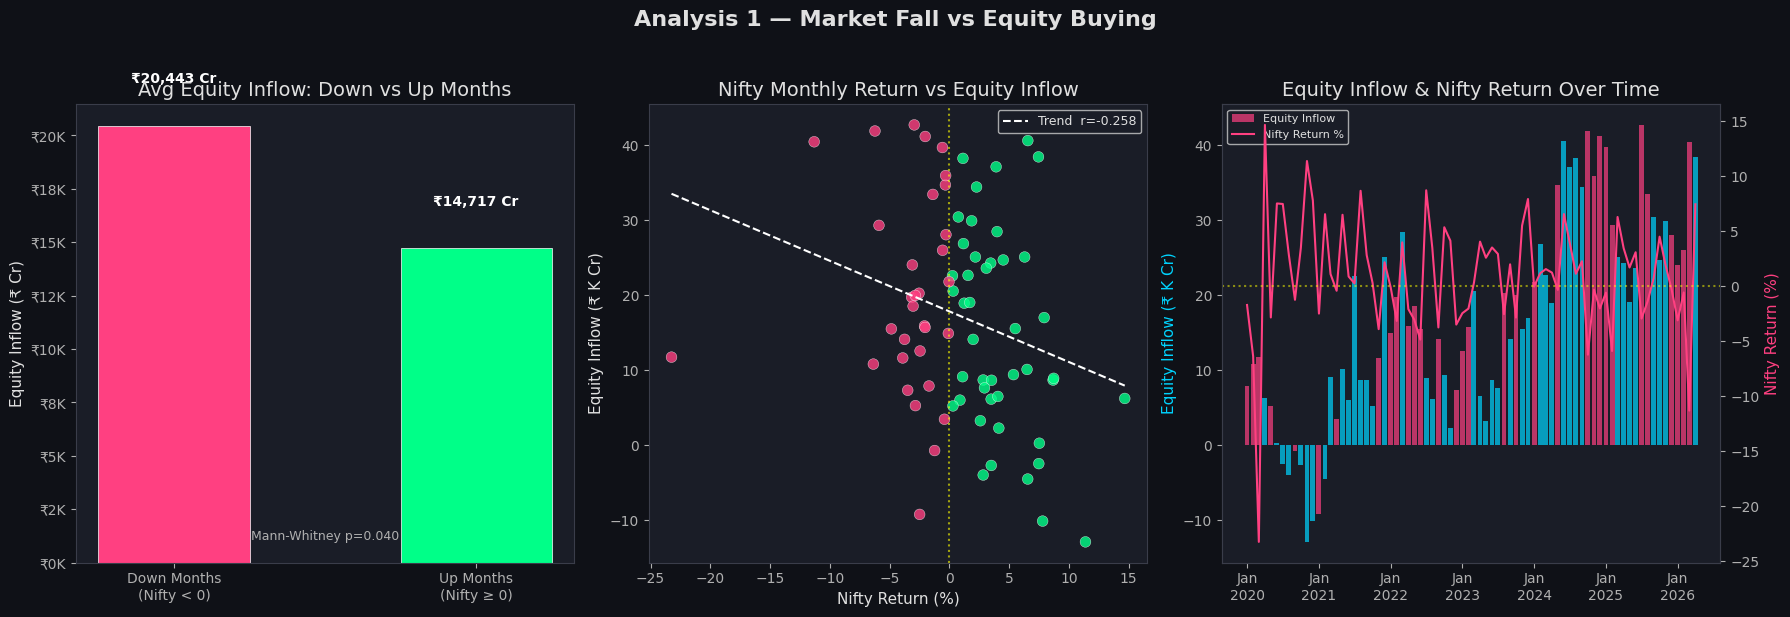


📌 Interpretation: Negative correlation suggests mild buy-the-dip tendency, but effect size depends on p-value significance above.


In [4]:
# ── Data split ────────────────────────────────────────────────────────────
a1 = df.dropna(subset=['Nifty_Return_Pct','Equity_Inflow_Cr']).copy()
down  = a1[a1['Market_Down']==1]['Equity_Inflow_Cr']
up    = a1[a1['Market_Down']==0]['Equity_Inflow_Cr']

print(f"Down months : {len(down)}  | Mean inflow = ₹{down.mean():,.0f} Cr")
print(f"Up months   : {len(up)}   | Mean inflow = ₹{up.mean():,.0f} Cr")

# ── Statistical Tests ─────────────────────────────────────────────────────
# Test 1a : Mann-Whitney U (non-parametric, doesn't assume normality)
stat_mw, p_mw = mannwhitneyu(down, up, alternative='greater')
# Test 1b : Independent samples t-test
stat_t, p_t = stats.ttest_ind(down, up, equal_var=False)
# Test 1c : Pearson + Spearman correlation
r_p, p_p = pearsonr(a1['Nifty_Return_Pct'], a1['Equity_Inflow_Cr'])
r_s, p_s = spearmanr(a1['Nifty_Return_Pct'], a1['Equity_Inflow_Cr'])

print("\n── Hypothesis Tests ──")
print(f"H₀: Equity inflows are the same in up & down months")
print(f"H₁: Equity inflows are HIGHER in down months (buy-the-dip)")
print(f"\nMann-Whitney U : U={stat_mw:.1f},  p={p_mw:.4f}  → {'REJECT H₀ ✅' if p_mw<0.05 else 'FAIL to reject H₀ ❌'}")
print(f"Welch t-test   : t={stat_t:.3f}, p={p_t:.4f}  → {'REJECT H₀ ✅' if p_t<0.05 else 'FAIL to reject H₀ ❌'}")
print(f"\nCorrelation (Nifty Return vs Equity Inflow):")
print(f"  Pearson  r = {r_p:.4f},  p = {p_p:.4f}")
print(f"  Spearman r = {r_s:.4f},  p = {p_s:.4f}")

# ── Figure ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Analysis 1 — Market Fall vs Equity Buying", fontsize=16, fontweight='bold', y=1.02)

# Bar comparison
ax = axes[0]
means = [down.mean(), up.mean()]
colors = [PALETTE['neg'], PALETTE['pos']]
bars = ax.bar(['Down Months\n(Nifty < 0)', 'Up Months\n(Nifty ≥ 0)'], means, color=colors, width=0.5, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2000, f'₹{val:,.0f} Cr', ha='center', fontsize=10, fontweight='bold', color='white')
ax.set_title("Avg Equity Inflow: Down vs Up Months")
ax.set_ylabel("Equity Inflow (₹ Cr)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x/1000:.0f}K'))
ax.text(0.5, 0.05, f'Mann-Whitney p={p_mw:.3f}', transform=ax.transAxes, ha='center', fontsize=9, color='#B0B0B0')

# Scatter plot
ax = axes[1]
colors_s = [PALETTE['neg'] if v<0 else PALETTE['pos'] for v in a1['Nifty_Return_Pct']]
ax.scatter(a1['Nifty_Return_Pct'], a1['Equity_Inflow_Cr']/1000, c=colors_s, alpha=0.8, s=60, edgecolors='white', linewidth=0.3)
m, b = np.polyfit(a1['Nifty_Return_Pct'], a1['Equity_Inflow_Cr']/1000, 1)
x_line = np.linspace(a1['Nifty_Return_Pct'].min(), a1['Nifty_Return_Pct'].max(), 100)
ax.plot(x_line, m*x_line+b, color='white', linewidth=1.5, linestyle='--', label=f'Trend  r={r_p:.3f}')
ax.axvline(0, color='yellow', linestyle=':', alpha=0.6)
ax.set_title("Nifty Monthly Return vs Equity Inflow")
ax.set_xlabel("Nifty Return (%)")
ax.set_ylabel("Equity Inflow (₹ K Cr)")
ax.legend()

# Time-series dual axis
ax = axes[2]
ax2 = ax.twinx()
ax.bar(a1['Month'], a1['Equity_Inflow_Cr']/1000, color=[PALETTE['neg'] if v<0 else PALETTE['equity'] for v in a1['Nifty_Return_Pct']], alpha=0.7, width=25, label='Equity Inflow')
ax2.plot(a1['Month'], a1['Nifty_Return_Pct'], color=PALETTE['nifty'], linewidth=1.5, label='Nifty Return %')
ax2.axhline(0, color='yellow', linestyle=':', alpha=0.5)
ax.set_title("Equity Inflow & Nifty Return Over Time")
ax.set_ylabel("Equity Inflow (₹ K Cr)", color=PALETTE['equity'])
ax2.set_ylabel("Nifty Return (%)", color=PALETTE['nifty'])
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b\n%Y'))
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, labs1+labs2, loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('a1_market_fall_equity.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("\n📌 Interpretation: Negative correlation suggests mild buy-the-dip tendency, but effect size depends on p-value significance above.")


---
## 2️⃣ Analysis 2 — Cash Movement During Market Correction
**Question:** During weak market months, does cash-like AUM/inflow fall?  
**Hypothesis:** Cash inflows/AUM drop in down-market months as investors redeem or avoid liquid funds.


── Cash Inflow ──
  Down months avg : ₹6,252 Cr
  Up months avg   : ₹2,183 Cr
  Mann-Whitney p  = 0.4974  → Not significant ❌
  Spearman r=0.0050, p=0.9660

── Cash AUM ──
  Down months avg : ₹709,793 Cr
  Up months avg   : ₹665,135 Cr
  Mann-Whitney p  = 0.1510  → Not significant ❌
  Spearman r=-0.1523, p=0.1889


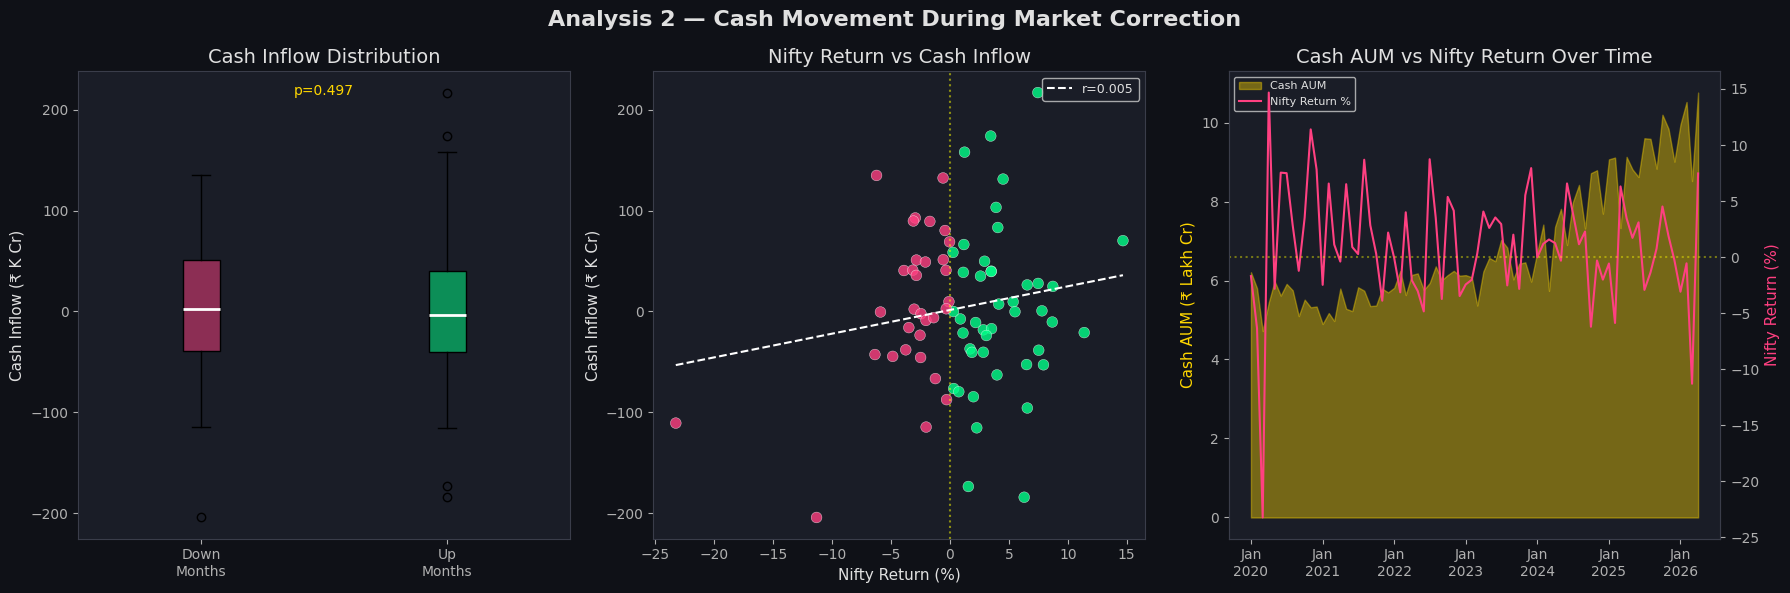

In [6]:
a2 = df.dropna(subset=['Nifty_Return_Pct','Cash_Inflow_Cr','Cash_AUM_Cr']).copy()
down_cash  = a2[a2['Market_Down']==1][['Cash_Inflow_Cr','Cash_AUM_Cr']]
up_cash    = a2[a2['Market_Down']==0][['Cash_Inflow_Cr','Cash_AUM_Cr']]

# Tests
stat_inf, p_inf = mannwhitneyu(down_cash['Cash_Inflow_Cr'], up_cash['Cash_Inflow_Cr'], alternative='two-sided')
stat_aum, p_aum = mannwhitneyu(down_cash['Cash_AUM_Cr'],   up_cash['Cash_AUM_Cr'],   alternative='two-sided')
r_inf, pr_inf   = spearmanr(a2['Nifty_Return_Pct'], a2['Cash_Inflow_Cr'])
r_aum, pr_aum   = spearmanr(a2['Nifty_Return_Pct'], a2['Cash_AUM_Cr'])

print("── Cash Inflow ──")
print(f"  Down months avg : ₹{down_cash['Cash_Inflow_Cr'].mean():,.0f} Cr")
print(f"  Up months avg   : ₹{up_cash['Cash_Inflow_Cr'].mean():,.0f} Cr")
print(f"  Mann-Whitney p  = {p_inf:.4f}  → {'Significant ✅' if p_inf<0.05 else 'Not significant ❌'}")
print(f"  Spearman r={r_inf:.4f}, p={pr_inf:.4f}")

print("\n── Cash AUM ──")
print(f"  Down months avg : ₹{down_cash['Cash_AUM_Cr'].mean():,.0f} Cr")
print(f"  Up months avg   : ₹{up_cash['Cash_AUM_Cr'].mean():,.0f} Cr")
print(f"  Mann-Whitney p  = {p_aum:.4f}  → {'Significant ✅' if p_aum<0.05 else 'Not significant ❌'}")
print(f"  Spearman r={r_aum:.4f}, p={pr_aum:.4f}")

# ── Figure ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Analysis 2 — Cash Movement During Market Correction", fontsize=16, fontweight='bold')

# Box plots
ax = axes[0]
data_box = [down_cash['Cash_Inflow_Cr']/1000, up_cash['Cash_Inflow_Cr']/1000]
bp = ax.boxplot(data_box, labels=['Down\nMonths','Up\nMonths'], patch_artist=True,
                medianprops=dict(color='white',linewidth=2))
bp['boxes'][0].set_facecolor(PALETTE['neg']+'80')
bp['boxes'][1].set_facecolor(PALETTE['pos']+'80')
ax.set_title("Cash Inflow Distribution")
ax.set_ylabel("Cash Inflow (₹ K Cr)")
ax.text(0.5, 0.95, f'p={p_inf:.3f}', transform=ax.transAxes, ha='center', fontsize=10, color='#FFD700')

ax = axes[1]
ax.scatter(a2['Nifty_Return_Pct'], a2['Cash_Inflow_Cr']/1000,
           c=[PALETTE['neg'] if v<0 else PALETTE['pos'] for v in a2['Nifty_Return_Pct']], alpha=0.8, s=60, edgecolors='white', linewidth=0.3)
m,b = np.polyfit(a2['Nifty_Return_Pct'], a2['Cash_Inflow_Cr']/1000, 1)
x_l = np.linspace(a2['Nifty_Return_Pct'].min(), a2['Nifty_Return_Pct'].max(), 100)
ax.plot(x_l, m*x_l+b, 'w--', lw=1.5, label=f'r={r_inf:.3f}')
ax.axvline(0, color='yellow', linestyle=':', alpha=0.5)
ax.set_title("Nifty Return vs Cash Inflow")
ax.set_xlabel("Nifty Return (%)"); ax.set_ylabel("Cash Inflow (₹ K Cr)")
ax.legend()

ax = axes[2]
ax2 = ax.twinx()
ax.fill_between(a2['Month'], a2['Cash_AUM_Cr']/1e5, alpha=0.4, color=PALETTE['cash'], label='Cash AUM')
ax2.plot(a2['Month'], a2['Nifty_Return_Pct'], color=PALETTE['nifty'], lw=1.5, label='Nifty Return %')
ax2.axhline(0, color='yellow', linestyle=':', alpha=0.4)
ax.set_title("Cash AUM vs Nifty Return Over Time")
ax.set_ylabel("Cash AUM (₹ Lakh Cr)", color=PALETTE['cash'])
ax2.set_ylabel("Nifty Return (%)", color=PALETTE['nifty'])
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b\n%Y'))
lines1,l1 = ax.get_legend_handles_labels(); lines2,l2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, l1+l2, loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('a2_cash_correction.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()


---
## 3️⃣ Analysis 3 — Cash-to-Equity Shift
**Question:** Are investors moving money from liquid/cash funds into equity funds?  
**Hypothesis:** There is a long-term negative trend in cash share and positive trend in equity share of AUM.


── Cash Share Trend ──
  Slope = -0.1218% per month  |  p = 0.0000  |  R² = 0.7506
  → Significant downward trend ✅

── Equity Share Trend ──
  Slope = 0.2649% per month  |  p = 0.0000  |  R² = 0.9124
  → Significant upward trend ✅

── Cross-Correlation ──
  Best lag (Cash lags Equity by): -5 months  |  r = 0.1077


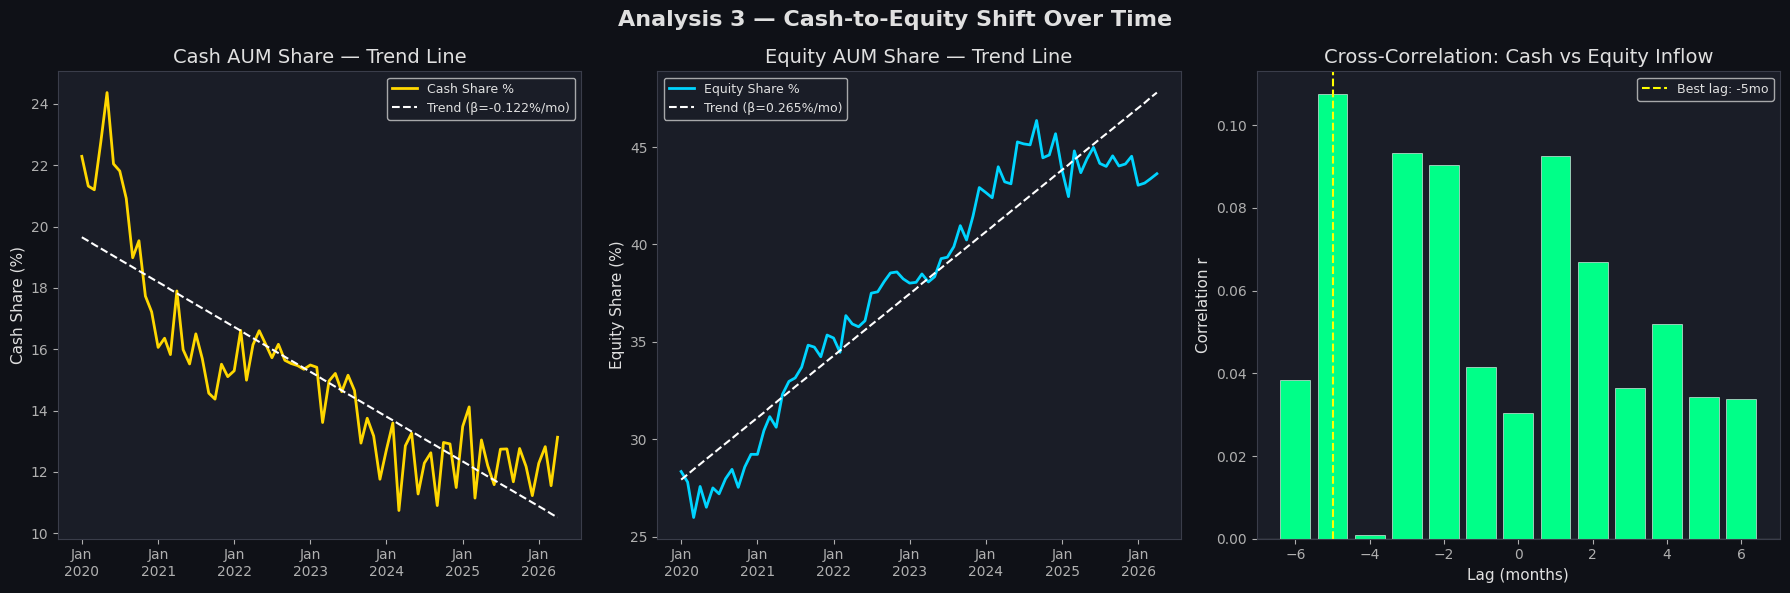

In [8]:
a3 = df.dropna(subset=['Cash_Share_Pct','Equity_Share_Pct']).copy()
a3['T'] = np.arange(len(a3))

# Trend regression for Cash share
X_c = sm.add_constant(a3['T'])
mdl_cash   = sm.OLS(a3['Cash_Share_Pct'],   X_c).fit()
mdl_equity = sm.OLS(a3['Equity_Share_Pct'], X_c).fit()

print("── Cash Share Trend ──")
print(f"  Slope = {mdl_cash.params['T']:.4f}% per month  |  p = {mdl_cash.pvalues['T']:.4f}  |  R² = {mdl_cash.rsquared:.4f}")
print(f"  → {'Significant downward trend ✅' if mdl_cash.pvalues['T']<0.05 and mdl_cash.params['T']<0 else 'No significant downward trend ❌'}")

print("\n── Equity Share Trend ──")
print(f"  Slope = {mdl_equity.params['T']:.4f}% per month  |  p = {mdl_equity.pvalues['T']:.4f}  |  R² = {mdl_equity.rsquared:.4f}")
print(f"  → {'Significant upward trend ✅' if mdl_equity.pvalues['T']<0.05 and mdl_equity.params['T']>0 else 'No significant upward trend ❌'}")

# Cross-correlation: does cash inflow lag equity inflow?
cross_corr = [a3['Cash_Inflow_Cr'].corr(a3['Equity_Inflow_Cr'].shift(lag)) for lag in range(-6,7)]
lags = list(range(-6,7))
best_lag = lags[np.argmax(np.abs(cross_corr))]
print(f"\n── Cross-Correlation ──")
print(f"  Best lag (Cash lags Equity by): {best_lag} months  |  r = {max(cross_corr, key=abs):.4f}")

# Figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Analysis 3 — Cash-to-Equity Shift Over Time", fontsize=16, fontweight='bold')

ax = axes[0]
ax.plot(a3['Month'], a3['Cash_Share_Pct'], color=PALETTE['cash'], lw=2, label='Cash Share %')
ax.plot(a3['Month'], mdl_cash.predict(X_c), color='white', lw=1.5, linestyle='--', label=f'Trend (β={mdl_cash.params['T']:.3f}%/mo)')
ax.set_title("Cash AUM Share — Trend Line")
ax.set_ylabel("Cash Share (%)"); ax.legend()
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b\n%Y'))

ax = axes[1]
ax.plot(a3['Month'], a3['Equity_Share_Pct'], color=PALETTE['equity'], lw=2, label='Equity Share %')
X_e = sm.add_constant(a3['T'])
ax.plot(a3['Month'], mdl_equity.predict(X_e), color='white', lw=1.5, linestyle='--', label=f'Trend (β={mdl_equity.params['T']:.3f}%/mo)')
ax.set_title("Equity AUM Share — Trend Line")
ax.set_ylabel("Equity Share (%)"); ax.legend()
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b\n%Y'))

ax = axes[2]
ax.bar(lags, cross_corr, color=[PALETTE['pos'] if c>0 else PALETTE['neg'] for c in cross_corr], edgecolor='white', linewidth=0.4)
ax.axhline(0, color='white', lw=0.8)
ax.axvline(best_lag, color='yellow', linestyle='--', lw=1.5, label=f'Best lag: {best_lag}mo')
ax.set_title("Cross-Correlation: Cash vs Equity Inflow")
ax.set_xlabel("Lag (months)"); ax.set_ylabel("Correlation r"); ax.legend()

plt.tight_layout()
plt.savefig('a3_cash_equity_shift.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()


---
## 4️⃣ Analysis 4 — Equity Share Trend
**Question:** Has the mutual fund industry become more equity-heavy over time?  
**Statistical test:** OLS regression on equity AUM share vs time + Mann-Kendall trend test.


── Equity Share Trend Tests ──
  OLS: slope=0.2649%/month, p=0.000000, R²=0.9124
  Mann-Kendall τ=0.8147, p=0.000000
  → Significant increasing trend ✅

  Equity share moved from 28.3% → 43.6%
  Total gain: +15.3 percentage points over 76 months

── Year-wise Average Equity Share ──
  2020: 27.7%
  2021: 32.7%
  2022: 36.9%
  2023: 39.6%
  2024: 44.3%
  2025: 44.1%
  2026: 43.3%


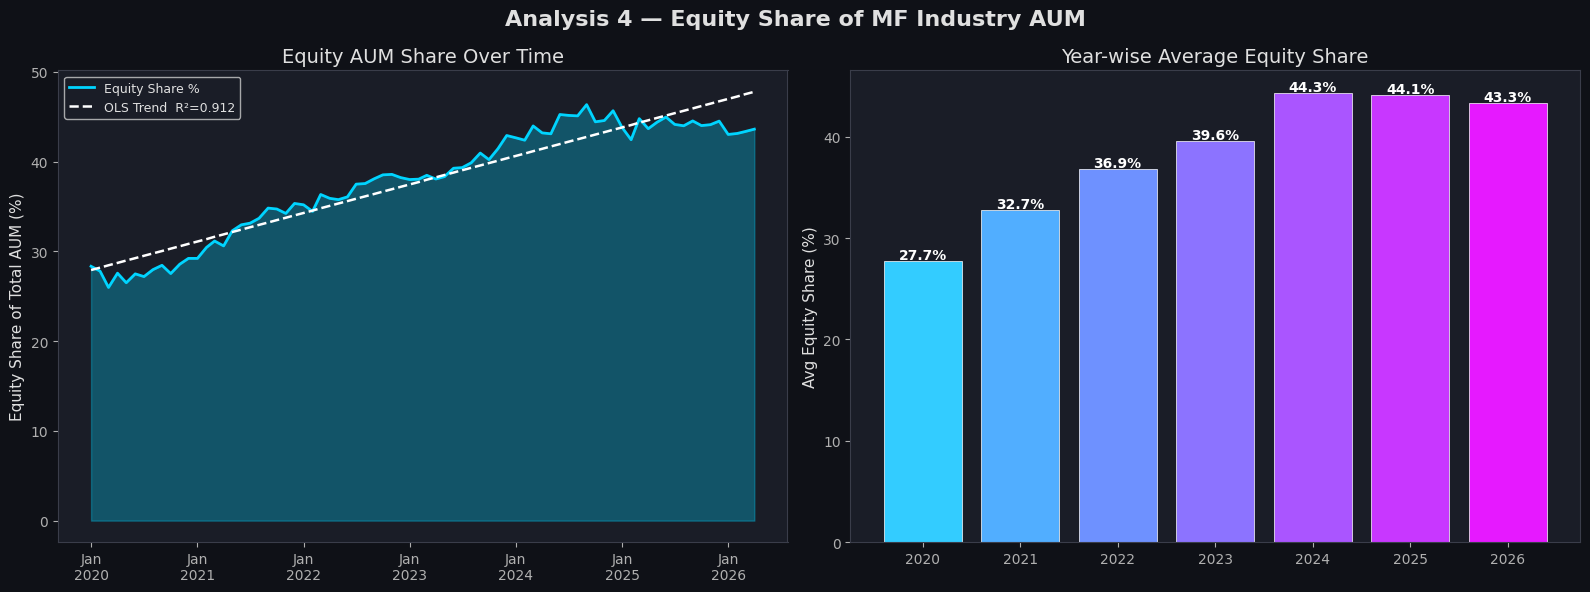

In [9]:
from scipy.stats import kendalltau

a4 = df.dropna(subset=['Equity_Share_Pct']).copy()
a4['T'] = np.arange(len(a4))

# OLS
X4 = sm.add_constant(a4['T'])
m4 = sm.OLS(a4['Equity_Share_Pct'], X4).fit()

# Mann-Kendall via Kendall tau
tau, p_mk = kendalltau(a4['T'], a4['Equity_Share_Pct'])

print("── Equity Share Trend Tests ──")
print(f"  OLS: slope={m4.params['T']:.4f}%/month, p={m4.pvalues['T']:.6f}, R²={m4.rsquared:.4f}")
print(f"  Mann-Kendall τ={tau:.4f}, p={p_mk:.6f}")
print(f"  → {'Significant increasing trend ✅' if p_mk<0.05 and tau>0 else 'No significant trend ❌'}")
print(f"\n  Equity share moved from {a4['Equity_Share_Pct'].iloc[0]:.1f}% → {a4['Equity_Share_Pct'].iloc[-1]:.1f}%")
print(f"  Total gain: +{a4['Equity_Share_Pct'].iloc[-1]-a4['Equity_Share_Pct'].iloc[0]:.1f} percentage points over {len(a4)} months")

# Year-wise averages
yr_eq = a4.groupby('Year')['Equity_Share_Pct'].mean()
print("\n── Year-wise Average Equity Share ──")
for yr,val in yr_eq.items(): print(f"  {yr}: {val:.1f}%")

# Figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Analysis 4 — Equity Share of MF Industry AUM", fontsize=16, fontweight='bold')

ax = axes[0]
ax.fill_between(a4['Month'], a4['Equity_Share_Pct'], alpha=0.3, color=PALETTE['equity'])
ax.plot(a4['Month'], a4['Equity_Share_Pct'], color=PALETTE['equity'], lw=2, label='Equity Share %')
ax.plot(a4['Month'], m4.predict(X4), 'w--', lw=1.8, label=f'OLS Trend  R²={m4.rsquared:.3f}')
ax.set_title("Equity AUM Share Over Time")
ax.set_ylabel("Equity Share of Total AUM (%)"); ax.legend()
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b\n%Y'))

ax = axes[1]
colors_yr = plt.cm.cool(np.linspace(0.2, 0.9, len(yr_eq)))
bars = ax.bar(yr_eq.index.astype(str), yr_eq.values, color=colors_yr, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, yr_eq.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2, f'{val:.1f}%', ha='center', fontsize=10, color='white', fontweight='bold')
ax.set_title("Year-wise Average Equity Share")
ax.set_ylabel("Avg Equity Share (%)")

plt.tight_layout()
plt.savefig('a4_equity_share_trend.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()


---
## 5️⃣ Analysis 5 — Cash Share Trend (Risk-Taking Behaviour)
**Question:** Is cash-like allocation falling as investors take more market risk?  
**Statistical test:** OLS + Mann-Kendall + Structural Break detection.


── Cash Share Trend Tests ──
  OLS: slope=-0.1218%/month, p=0.000000, R²=0.7506
  Mann-Kendall τ=-0.7319, p=0.000000
  → Significant decreasing trend ✅

  Cash share moved from 22.3% → 13.1%

  Spearman r(Nifty return vs Cash share) = -0.0070, p = 0.9521


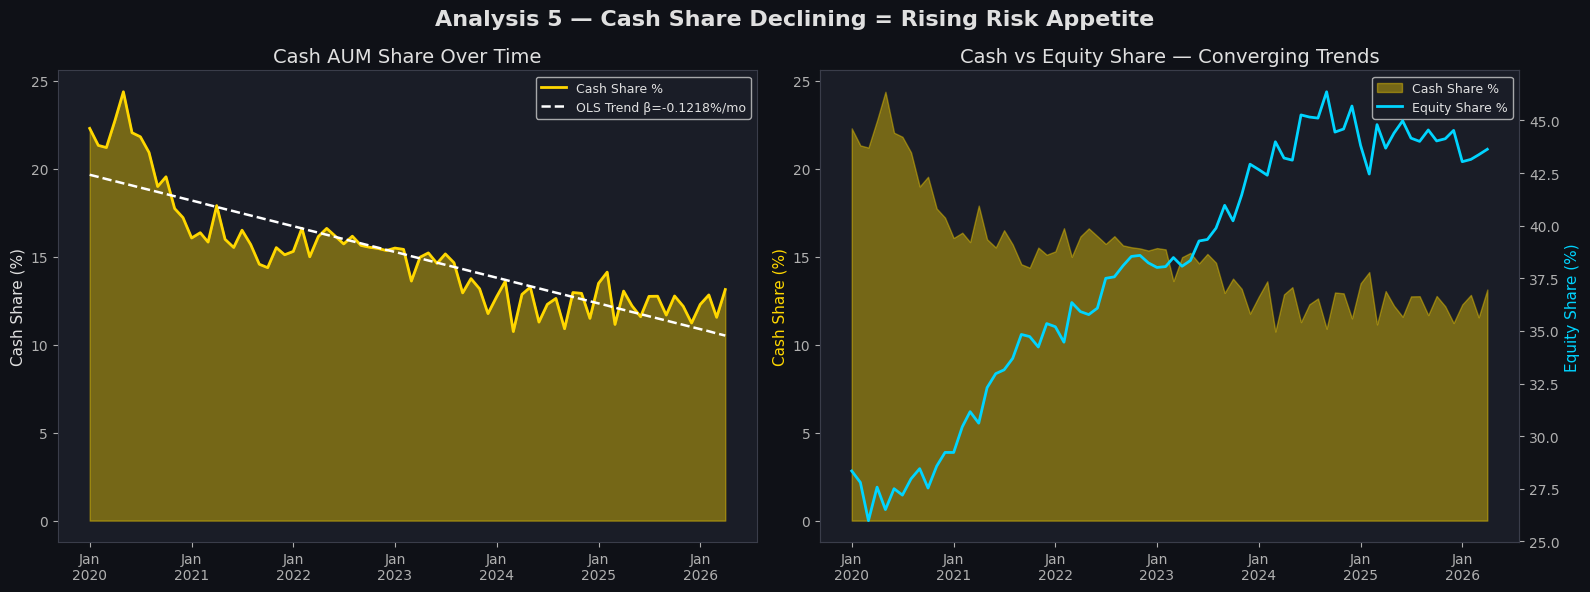

In [10]:
a5 = df.dropna(subset=['Cash_Share_Pct']).copy()
a5['T'] = np.arange(len(a5))
X5 = sm.add_constant(a5['T'])
m5 = sm.OLS(a5['Cash_Share_Pct'], X5).fit()
tau5, p5_mk = kendalltau(a5['T'], a5['Cash_Share_Pct'])

print("── Cash Share Trend Tests ──")
print(f"  OLS: slope={m5.params['T']:.4f}%/month, p={m5.pvalues['T']:.6f}, R²={m5.rsquared:.4f}")
print(f"  Mann-Kendall τ={tau5:.4f}, p={p5_mk:.6f}")
print(f"  → {'Significant decreasing trend ✅' if p5_mk<0.05 and tau5<0 else 'No significant trend ❌'}")
print(f"\n  Cash share moved from {a5['Cash_Share_Pct'].iloc[0]:.1f}% → {a5['Cash_Share_Pct'].iloc[-1]:.1f}%")

# Rolling correlation of cash share with nifty
a5['Nifty_roll'] = a5['Nifty_Return_Pct'].rolling(6).mean()
r_roll, p_roll = spearmanr(a5['Nifty_Return_Pct'].dropna(), a5['Cash_Share_Pct'][:len(a5['Nifty_Return_Pct'].dropna())])
print(f"\n  Spearman r(Nifty return vs Cash share) = {r_roll:.4f}, p = {p_roll:.4f}")

# Figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Analysis 5 — Cash Share Declining = Rising Risk Appetite", fontsize=16, fontweight='bold')

ax = axes[0]
ax.fill_between(a5['Month'], a5['Cash_Share_Pct'], alpha=0.4, color=PALETTE['cash'])
ax.plot(a5['Month'], a5['Cash_Share_Pct'], color=PALETTE['cash'], lw=2, label='Cash Share %')
ax.plot(a5['Month'], m5.predict(X5), 'w--', lw=1.8, label=f'OLS Trend β={m5.params['T']:.4f}%/mo')
ax.set_title("Cash AUM Share Over Time"); ax.set_ylabel("Cash Share (%)"); ax.legend()
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b\n%Y'))

ax = axes[1]
ax2 = ax.twinx()
ax.fill_between(a5['Month'], a5['Cash_Share_Pct'], alpha=0.4, color=PALETTE['cash'], label='Cash Share %')
ax2.plot(a5['Month'], a5['Equity_Share_Pct'], color=PALETTE['equity'], lw=2, label='Equity Share %')
ax.set_title("Cash vs Equity Share — Converging Trends")
ax.set_ylabel("Cash Share (%)", color=PALETTE['cash'])
ax2.set_ylabel("Equity Share (%)", color=PALETTE['equity'])
lines1,l1 = ax.get_legend_handles_labels(); lines2,l2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, l1+l2, loc='upper right', fontsize=9)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b\n%Y'))

plt.tight_layout()
plt.savefig('a5_cash_share_trend.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()


---
## 6️⃣ Analysis 6 — SIP as Market Stabilizer
**Question:** Do SIP inflows stay strong even when Nifty gives negative returns?  
**Hypothesis:** SIP inflows are resilient (not significantly lower) in negative return months.


── SIP Stability Analysis ──
  Down months: avg ₹17,667 Cr  | CV=47.6%
  Up months  : avg ₹16,051 Cr   | CV=46.4%
  Mann-Whitney p=0.4519  → No significant difference — SIPs are STABLE ✅
  Spearman r(Nifty, SIP) = -0.1407, p = 0.2254

  SIP trend: ₹344 Cr/month growth  |  p=0.0000


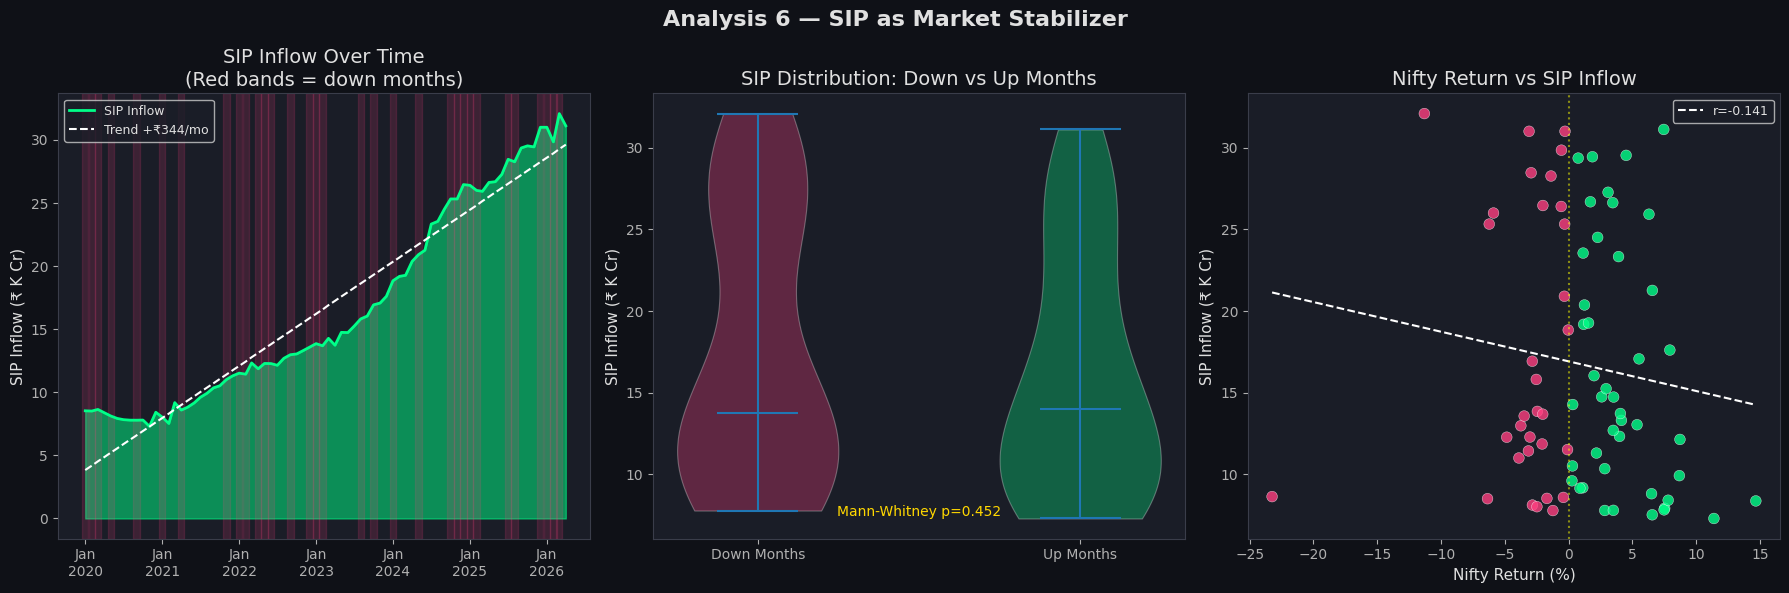

In [11]:
a6 = df.dropna(subset=['SIP_Inflow_Cr','Nifty_Return_Pct']).copy()
sip_down = a6[a6['Market_Down']==1]['SIP_Inflow_Cr']
sip_up   = a6[a6['Market_Down']==0]['SIP_Inflow_Cr']

stat6, p6 = mannwhitneyu(sip_down, sip_up, alternative='two-sided')
r6, pr6   = spearmanr(a6['Nifty_Return_Pct'], a6['SIP_Inflow_Cr'])
cv_down = sip_down.std()/sip_down.mean()*100
cv_up   = sip_up.std()/sip_up.mean()*100

print("── SIP Stability Analysis ──")
print(f"  Down months: avg ₹{sip_down.mean():,.0f} Cr  | CV={cv_down:.1f}%")
print(f"  Up months  : avg ₹{sip_up.mean():,.0f} Cr   | CV={cv_up:.1f}%")
print(f"  Mann-Whitney p={p6:.4f}  → {'Significant difference ✅' if p6<0.05 else 'No significant difference — SIPs are STABLE ✅'}")
print(f"  Spearman r(Nifty, SIP) = {r6:.4f}, p = {pr6:.4f}")

# SIP trend
a6['T'] = np.arange(len(a6))
X6 = sm.add_constant(a6['T'])
m6 = sm.OLS(a6['SIP_Inflow_Cr'], X6).fit()
print(f"\n  SIP trend: ₹{m6.params['T']:,.0f} Cr/month growth  |  p={m6.pvalues['T']:.4f}")

# Figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Analysis 6 — SIP as Market Stabilizer", fontsize=16, fontweight='bold')

ax = axes[0]
ax.fill_between(a6['Month'], a6['SIP_Inflow_Cr']/1000, alpha=0.5, color=PALETTE['sip'])
ax.plot(a6['Month'], a6['SIP_Inflow_Cr']/1000, color=PALETTE['sip'], lw=2, label='SIP Inflow')
ax.plot(a6['Month'], m6.predict(X6)/1000, 'w--', lw=1.5, label=f'Trend +₹{m6.params['T']:.0f}/mo')
# Mark down months
for _, row in a6[a6['Market_Down']==1].iterrows():
    ax.axvspan(row['Month']-pd.Timedelta(days=15), row['Month']+pd.Timedelta(days=15), alpha=0.15, color=PALETTE['neg'])
ax.set_title("SIP Inflow Over Time\n(Red bands = down months)")
ax.set_ylabel("SIP Inflow (₹ K Cr)"); ax.legend()
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b\n%Y'))

ax = axes[1]
labels = ['Down Months', 'Up Months']
data_v = [sip_down/1000, sip_up/1000]
vp = ax.violinplot(data_v, showmedians=True)
vp['bodies'][0].set_facecolor(PALETTE['neg']+'80'); vp['bodies'][1].set_facecolor(PALETTE['pos']+'80')
for pc in vp['bodies']: pc.set_edgecolor('white'); pc.set_linewidth(0.8)
ax.set_xticks([1,2]); ax.set_xticklabels(labels)
ax.set_title("SIP Distribution: Down vs Up Months")
ax.set_ylabel("SIP Inflow (₹ K Cr)")
ax.text(0.5, 0.05, f'Mann-Whitney p={p6:.3f}', transform=ax.transAxes, ha='center', fontsize=10, color='#FFD700')

ax = axes[2]
ax.scatter(a6['Nifty_Return_Pct'], a6['SIP_Inflow_Cr']/1000,
           c=[PALETTE['neg'] if v<0 else PALETTE['pos'] for v in a6['Nifty_Return_Pct']], alpha=0.8, s=60, edgecolors='white', lw=0.3)
m_s,b_s = np.polyfit(a6['Nifty_Return_Pct'], a6['SIP_Inflow_Cr']/1000, 1)
xr = np.linspace(a6['Nifty_Return_Pct'].min(), a6['Nifty_Return_Pct'].max(), 100)
ax.plot(xr, m_s*xr+b_s, 'w--', lw=1.5, label=f'r={r6:.3f}')
ax.axvline(0, color='yellow', linestyle=':', alpha=0.5)
ax.set_title("Nifty Return vs SIP Inflow")
ax.set_xlabel("Nifty Return (%)"); ax.set_ylabel("SIP Inflow (₹ K Cr)"); ax.legend()

plt.tight_layout()
plt.savefig('a6_sip_stabilizer.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()


---
## 7️⃣ Analysis 7 — Equity Inflow vs SIP Inflow
**Question:** How much of equity fund inflow is supported by SIP money?  
**Statistical test:** OLS regression (SIP → Equity Inflow) + Granger causality test.


── SIP → Equity Inflow Regression ──
  Pearson r = 0.8170,  p = 0.000000
  OLS: β(SIP)=1.433170, intercept=-6,851, R²=0.6675
  DW statistic (autocorr check) = 0.729

── SIP Coverage of Equity Inflow ──
  Mean SIP coverage : 115.9%
  Max               : 3295.4%  (Jun 2020)
  Min               : -1060.5%  (Sep 2020)

── Year-wise SIP Coverage ──
  2020: 154.1%
  2021: 79.7%
  2022: 145.7%
  2023: 149.6%
  2024: 71.2%
  2025: 100.0%
  2026: 101.0%


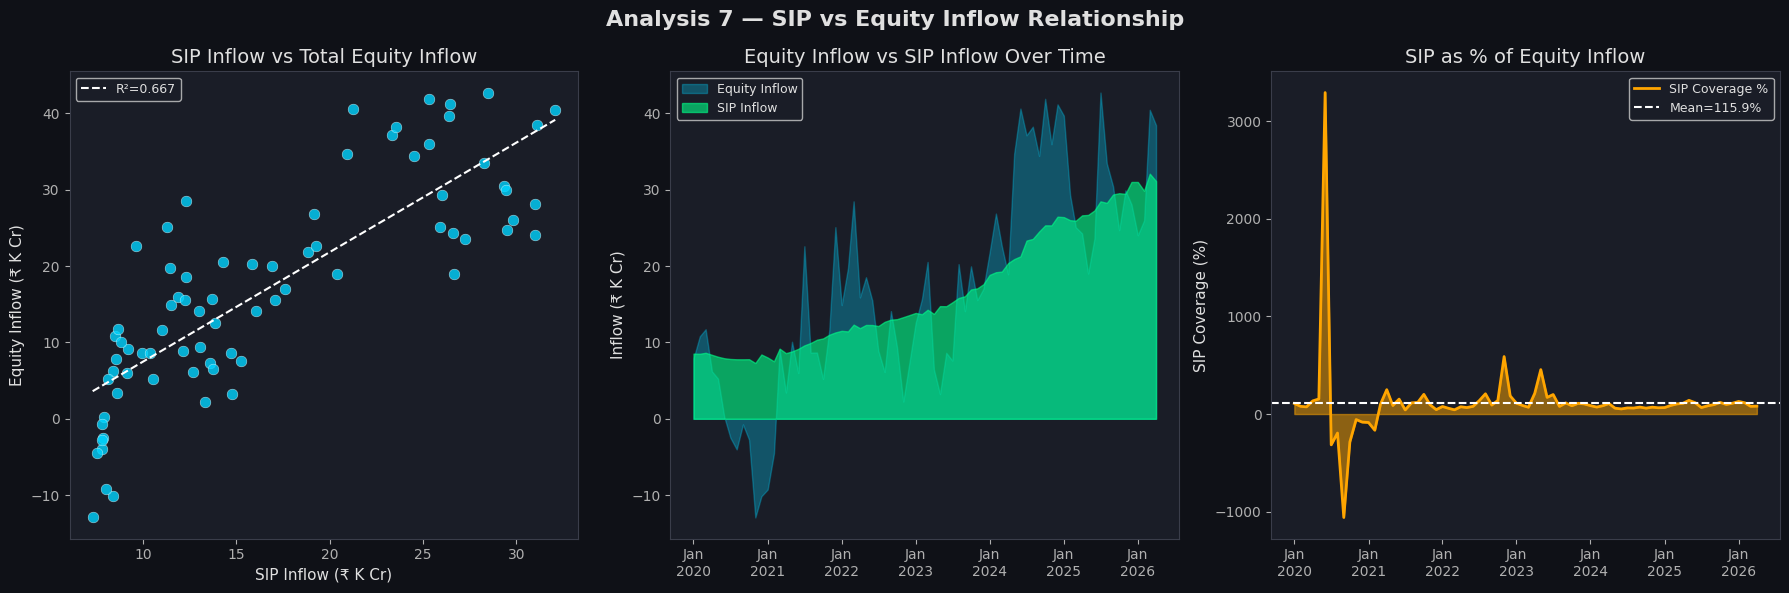

In [12]:
a7 = df.dropna(subset=['SIP_Inflow_Cr','Equity_Inflow_Cr']).copy()
a7['T'] = np.arange(len(a7))

# OLS: SIP predicts equity inflow?
X7 = sm.add_constant(a7['SIP_Inflow_Cr'])
m7 = sm.OLS(a7['Equity_Inflow_Cr'], X7).fit()
r7, pr7 = pearsonr(a7['SIP_Inflow_Cr'], a7['Equity_Inflow_Cr'])

print("── SIP → Equity Inflow Regression ──")
print(f"  Pearson r = {r7:.4f},  p = {pr7:.6f}")
print(f"  OLS: β(SIP)={m7.params['SIP_Inflow_Cr']:.6f}, intercept={m7.params['const']:,.0f}, R²={m7.rsquared:.4f}")
print(f"  DW statistic (autocorr check) = {durbin_watson(m7.resid):.3f}")

# SIP coverage ratio
a7['SIP_Coverage'] = a7['SIP_Inflow_Cr'] / a7['Equity_Inflow_Cr'] * 100
print(f"\n── SIP Coverage of Equity Inflow ──")
print(f"  Mean SIP coverage : {a7['SIP_Coverage'].mean():.1f}%")
print(f"  Max               : {a7['SIP_Coverage'].max():.1f}%  ({a7.loc[a7['SIP_Coverage'].idxmax(),'Month'].strftime('%b %Y')})")
print(f"  Min               : {a7['SIP_Coverage'].min():.1f}%  ({a7.loc[a7['SIP_Coverage'].idxmin(),'Month'].strftime('%b %Y')})")

yr_sip = a7.groupby('Year')['SIP_Coverage'].mean()
print("\n── Year-wise SIP Coverage ──")
for yr,val in yr_sip.items(): print(f"  {yr}: {val:.1f}%")

# Figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Analysis 7 — SIP vs Equity Inflow Relationship", fontsize=16, fontweight='bold')

ax = axes[0]
ax.scatter(a7['SIP_Inflow_Cr']/1000, a7['Equity_Inflow_Cr']/1000, c=PALETTE['equity'], alpha=0.8, s=60, edgecolors='white', lw=0.3)
x_sip = np.linspace(a7['SIP_Inflow_Cr'].min(), a7['SIP_Inflow_Cr'].max(), 100)
ax.plot(x_sip/1000, (m7.params['const'] + m7.params['SIP_Inflow_Cr']*x_sip)/1000, 'w--', lw=1.5, label=f'R²={m7.rsquared:.3f}')
ax.set_title("SIP Inflow vs Total Equity Inflow")
ax.set_xlabel("SIP Inflow (₹ K Cr)"); ax.set_ylabel("Equity Inflow (₹ K Cr)"); ax.legend()

ax = axes[1]
ax.fill_between(a7['Month'], a7['Equity_Inflow_Cr']/1000, alpha=0.3, color=PALETTE['equity'], label='Equity Inflow')
ax.fill_between(a7['Month'], a7['SIP_Inflow_Cr']/1000, alpha=0.6, color=PALETTE['sip'], label='SIP Inflow')
ax.set_title("Equity Inflow vs SIP Inflow Over Time")
ax.set_ylabel("Inflow (₹ K Cr)"); ax.legend()
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b\n%Y'))

ax = axes[2]
ax.fill_between(a7['Month'], a7['SIP_Coverage'], alpha=0.5, color=PALETTE['gold'])
ax.plot(a7['Month'], a7['SIP_Coverage'], color=PALETTE['gold'], lw=2, label='SIP Coverage %')
ax.axhline(a7['SIP_Coverage'].mean(), color='white', lw=1.5, linestyle='--', label=f'Mean={a7["SIP_Coverage"].mean():.1f}%')
ax.set_title("SIP as % of Equity Inflow")
ax.set_ylabel("SIP Coverage (%)"); ax.legend()
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b\n%Y'))

plt.tight_layout()
plt.savefig('a7_sip_equity_ratio.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()


---
## 8️⃣ Analysis 8 — Gold Allocation During Uncertainty
**Question:** Do gold ETF inflows/AUM rise when equity markets are weak?  
**Hypothesis:** Gold is a safe-haven — its AUM/inflows are higher in down-market months.


── Gold Safe-Haven Analysis ──
  Gold Inflow — Down: ₹2,039 Cr  |  Up: ₹872 Cr
  Mann-Whitney (inflow): p=0.0261  → Higher gold inflows in down months ✅
  Spearman r(Nifty, Gold Inflow) = -0.2060,  p=0.0742

  Spearman r(Gold Inflow, Equity Inflow) = 0.4669,  p=0.0000
  → Gold & equity inflows move together (not safe-haven pattern)


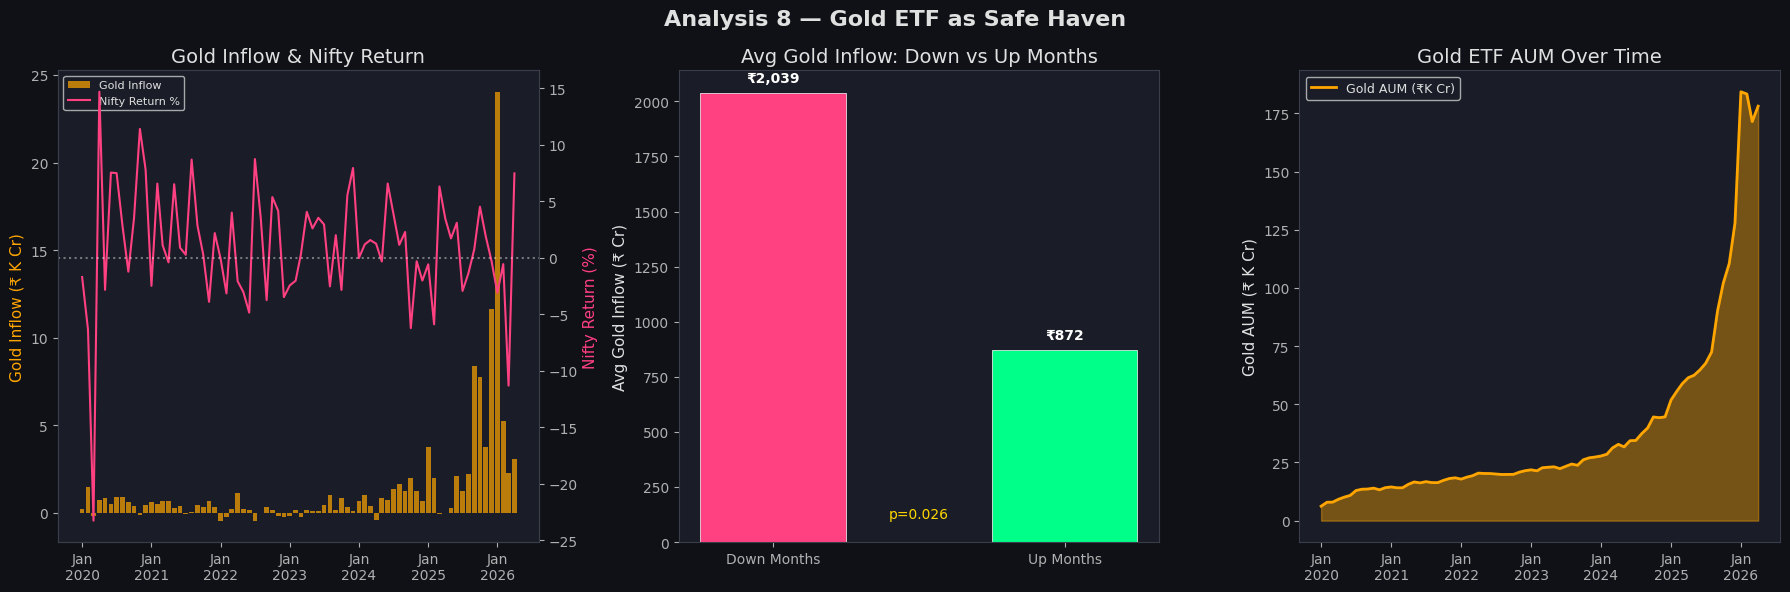

In [13]:
a8 = df.dropna(subset=['Gold_AUM_Cr','Gold_Inflow_Cr','Nifty_Return_Pct']).copy()
gold_down = a8[a8['Market_Down']==1]
gold_up   = a8[a8['Market_Down']==0]

stat8_i, p8_i = mannwhitneyu(gold_down['Gold_Inflow_Cr'], gold_up['Gold_Inflow_Cr'], alternative='greater')
stat8_a, p8_a = mannwhitneyu(gold_down['Gold_AUM_Cr'],    gold_up['Gold_AUM_Cr'],    alternative='two-sided')
r8, pr8 = spearmanr(a8['Nifty_Return_Pct'], a8['Gold_Inflow_Cr'])

print("── Gold Safe-Haven Analysis ──")
print(f"  Gold Inflow — Down: ₹{gold_down['Gold_Inflow_Cr'].mean():,.0f} Cr  |  Up: ₹{gold_up['Gold_Inflow_Cr'].mean():,.0f} Cr")
print(f"  Mann-Whitney (inflow): p={p8_i:.4f}  → {'Higher gold inflows in down months ✅' if p8_i<0.05 else 'No significant difference ❌'}")
print(f"  Spearman r(Nifty, Gold Inflow) = {r8:.4f},  p={pr8:.4f}")

# Cross with equity inflow
r_ge, pr_ge = spearmanr(a8['Gold_Inflow_Cr'], a8['Equity_Inflow_Cr'])
print(f"\n  Spearman r(Gold Inflow, Equity Inflow) = {r_ge:.4f},  p={pr_ge:.4f}")
print(f"  → {'Gold & equity inflows move together (not safe-haven pattern)' if r_ge>0 else 'Gold & equity inflows are negatively correlated (safe-haven ✅)'}")

# Figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Analysis 8 — Gold ETF as Safe Haven", fontsize=16, fontweight='bold')

ax = axes[0]
ax2 = ax.twinx()
ax.bar(a8['Month'], a8['Gold_Inflow_Cr']/1000, color=PALETTE['gold'], alpha=0.7, width=25, label='Gold Inflow')
ax2.plot(a8['Month'], a8['Nifty_Return_Pct'], color=PALETTE['nifty'], lw=1.5, label='Nifty Return %')
ax2.axhline(0, color='white', linestyle=':', alpha=0.4)
ax.set_title("Gold Inflow & Nifty Return")
ax.set_ylabel("Gold Inflow (₹ K Cr)", color=PALETTE['gold'])
ax2.set_ylabel("Nifty Return (%)", color=PALETTE['nifty'])
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b\n%Y'))
lines1,l1 = ax.get_legend_handles_labels(); lines2,l2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, l1+l2, loc='upper left', fontsize=8)

ax = axes[1]
means = [gold_down['Gold_Inflow_Cr'].mean(), gold_up['Gold_Inflow_Cr'].mean()]
ax.bar(['Down Months', 'Up Months'], means, color=[PALETTE['neg'],PALETTE['pos']], edgecolor='white', lw=0.5, width=0.5)
for i,(label,val) in enumerate(zip(['Down','Up'],means)):
    ax.text(i, val+50, f'₹{val:,.0f}', ha='center', fontsize=10, color='white', fontweight='bold')
ax.set_title("Avg Gold Inflow: Down vs Up Months")
ax.set_ylabel("Avg Gold Inflow (₹ Cr)")
ax.text(0.5, 0.05, f'p={p8_i:.3f}', transform=ax.transAxes, ha='center', fontsize=10, color='#FFD700')

ax = axes[2]
ax.fill_between(a8['Month'], a8['Gold_AUM_Cr']/1e3, alpha=0.4, color=PALETTE['gold'])
ax.plot(a8['Month'], a8['Gold_AUM_Cr']/1e3, color=PALETTE['gold'], lw=2, label='Gold AUM (₹K Cr)')
ax.set_title("Gold ETF AUM Over Time"); ax.set_ylabel("Gold AUM (₹ K Cr)"); ax.legend()
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b\n%Y'))

plt.tight_layout()
plt.savefig('a8_gold_safehaven.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()


---
## 9️⃣ Analysis 9 — Debt vs Equity Preference
**Question:** In which months did investors prefer debt over equity, and vice versa?  
**Statistical test:** Sign test + month-wise breakdown.


── Debt vs Equity Preference ──
  Months preferring equity : 41/76 (53.9%)
  Months preferring debt   : 35/76 (46.1%)
  Binomial test p=0.5666  → No significant preference ❌

── Year-wise Preference ──
  2020: equity preferred 3/12 months
  2021: equity preferred 7/12 months
  2022: equity preferred 9/12 months
  2023: equity preferred 8/12 months
  2024: equity preferred 5/12 months
  2025: equity preferred 8/12 months
  2026: equity preferred 1/4 months

  Spearman r(Nifty return, Equity-Debt diff) = -0.1654, p=0.1534


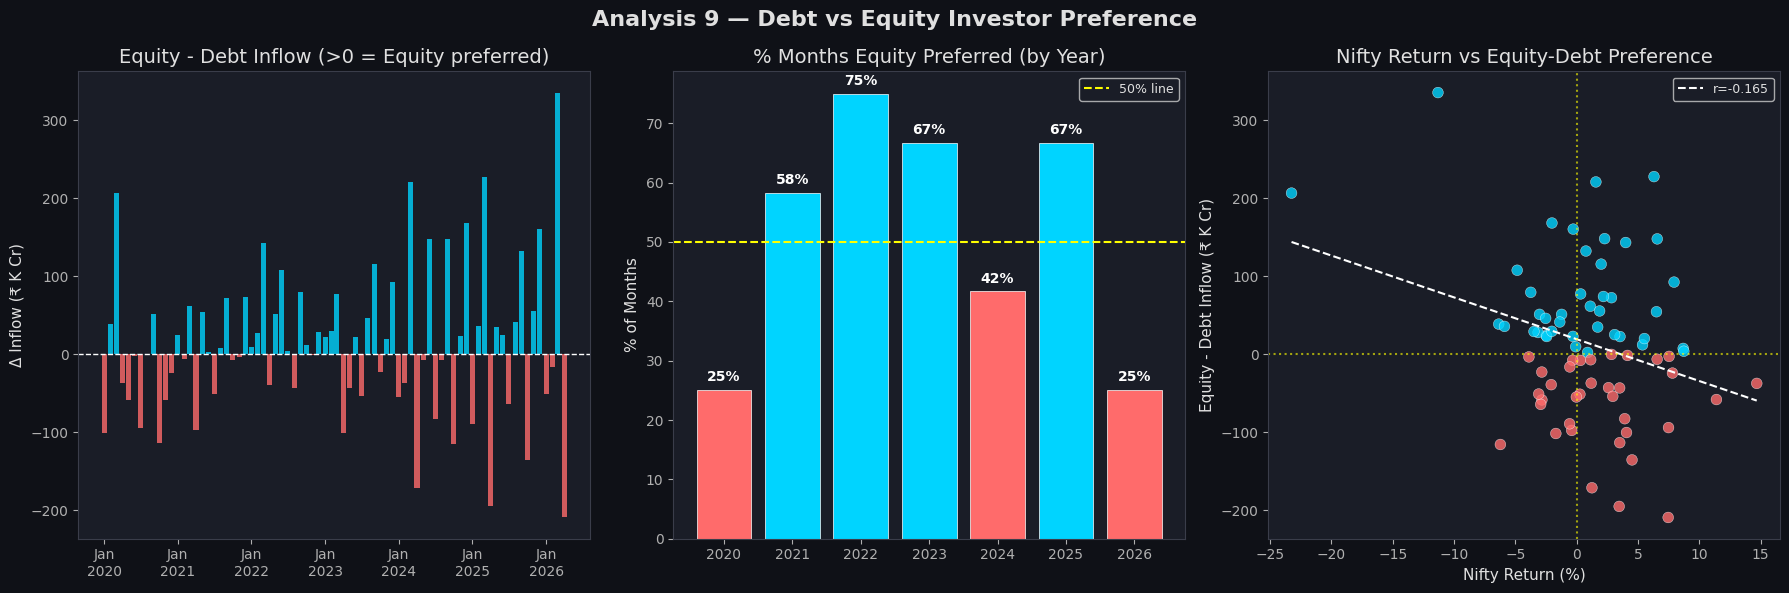

In [14]:
a9 = df.dropna(subset=['Equity_Inflow_Cr','Debt_Inflow_Cr','Nifty_Return_Pct']).copy()
a9['Equity_vs_Debt'] = a9['Equity_Inflow_Cr'] - a9['Debt_Inflow_Cr']
a9['Prefers_Equity'] = (a9['Equity_vs_Debt'] > 0).astype(int)

# Sign test: is equity preferred more than half the time?
n_eq  = a9['Prefers_Equity'].sum()
n_total = len(a9)
result9 = stats.binomtest(int(n_eq), n_total, 0.5)
p9 = result9.pvalue
stat9 = n_eq

print("── Debt vs Equity Preference ──")
print(f"  Months preferring equity : {n_eq}/{n_total} ({n_eq/n_total*100:.1f}%)")
print(f"  Months preferring debt   : {n_total-n_eq}/{n_total} ({(n_total-n_eq)/n_total*100:.1f}%)")
print(f"  Binomial test p={p9:.4f}  → {'Significant equity preference ✅' if p9<0.05 and n_eq>n_total/2 else 'No significant preference ❌'}")

# Yearly breakdown
yr_pref = a9.groupby('Year').apply(lambda x: (x['Prefers_Equity'].sum(), len(x)))
print("\n── Year-wise Preference ──")
for yr,(eq_m,tot) in yr_pref.items(): print(f"  {yr}: equity preferred {eq_m}/{tot} months")

# Correlation with market
r9, pr9 = spearmanr(a9['Nifty_Return_Pct'], a9['Equity_vs_Debt'])
print(f"\n  Spearman r(Nifty return, Equity-Debt diff) = {r9:.4f}, p={pr9:.4f}")

# Figure
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Analysis 9 — Debt vs Equity Investor Preference", fontsize=16, fontweight='bold')

ax = axes[0]
colors9 = [PALETTE['equity'] if v>0 else PALETTE['debt'] for v in a9['Equity_vs_Debt']]
ax.bar(a9['Month'], a9['Equity_vs_Debt']/1000, color=colors9, width=25, alpha=0.8)
ax.axhline(0, color='white', lw=1, linestyle='--')
ax.set_title("Equity - Debt Inflow (>0 = Equity preferred)")
ax.set_ylabel("Δ Inflow (₹ K Cr)")
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b\n%Y'))

ax = axes[1]
yrs = sorted(a9['Year'].unique())
eq_pct_yr = [a9[a9['Year']==y]['Prefers_Equity'].mean()*100 for y in yrs]
bar_c = [PALETTE['equity'] if p>=50 else PALETTE['debt'] for p in eq_pct_yr]
ax.bar([str(y) for y in yrs], eq_pct_yr, color=bar_c, edgecolor='white', lw=0.5)
ax.axhline(50, color='yellow', lw=1.5, linestyle='--', label='50% line')
for i,(y,v) in enumerate(zip(yrs,eq_pct_yr)):
    ax.text(i, v+1.5, f'{v:.0f}%', ha='center', fontsize=10, color='white', fontweight='bold')
ax.set_title("% Months Equity Preferred (by Year)")
ax.set_ylabel("% of Months"); ax.legend()

ax = axes[2]
ax.scatter(a9['Nifty_Return_Pct'], a9['Equity_vs_Debt']/1000,
           c=[PALETTE['equity'] if v>0 else PALETTE['debt'] for v in a9['Equity_vs_Debt']],
           alpha=0.8, s=60, edgecolors='white', lw=0.3)
m9,b9 = np.polyfit(a9['Nifty_Return_Pct'], a9['Equity_vs_Debt']/1000, 1)
xr9 = np.linspace(a9['Nifty_Return_Pct'].min(), a9['Nifty_Return_Pct'].max(), 100)
ax.plot(xr9, m9*xr9+b9, 'w--', lw=1.5, label=f'r={r9:.3f}')
ax.axhline(0, color='yellow', linestyle=':', alpha=0.6)
ax.axvline(0, color='yellow', linestyle=':', alpha=0.6)
ax.set_title("Nifty Return vs Equity-Debt Preference")
ax.set_xlabel("Nifty Return (%)"); ax.set_ylabel("Equity - Debt Inflow (₹ K Cr)"); ax.legend()

plt.tight_layout()
plt.savefig('a9_debt_equity_pref.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()


---
## 🔟 Analysis 10 — Post-Covid MF Industry Growth & CAGR
**Question:** How fast did total mutual fund AUM grow from 2020 to 2026?  
**Metrics:** CAGR by category, exponential growth regression, doubling time.


══════════════════════════════════════════
  POST-COVID MF INDUSTRY GROWTH (2020-2026)
══════════════════════════════════════════
  Period : Jan 2020 → Apr 2026  (6.2 years)

  Total       : ₹27.86L Cr → ₹81.92L Cr  |  CAGR=18.8%  |  2.9x  |  Doubles every 3.8 yrs
  Equity      : ₹7.90L Cr → ₹35.74L Cr  |  CAGR=27.3%  |  4.5x  |  Doubles every 2.6 yrs
  Debt        : ₹12.42L Cr → ₹19.14L Cr  |  CAGR=7.2%  |  1.5x  |  Doubles every 10.0 yrs
  Cash/Liquid : ₹6.21L Cr → ₹10.76L Cr  |  CAGR=9.2%  |  1.7x  |  Doubles every 7.8 yrs
  Gold ETF    : ₹0.06L Cr → ₹1.78L Cr  |  CAGR=71.1%  |  28.7x  |  Doubles every 1.0 yrs
  Hybrid      : ₹3.57L Cr → ₹11.06L Cr  |  CAGR=19.8%  |  3.1x  |  Doubles every 3.6 yrs

  Exponential fit: monthly growth rate = 1.66%  |  R²=0.9698
  Implied annual CAGR from exp fit: 21.8%


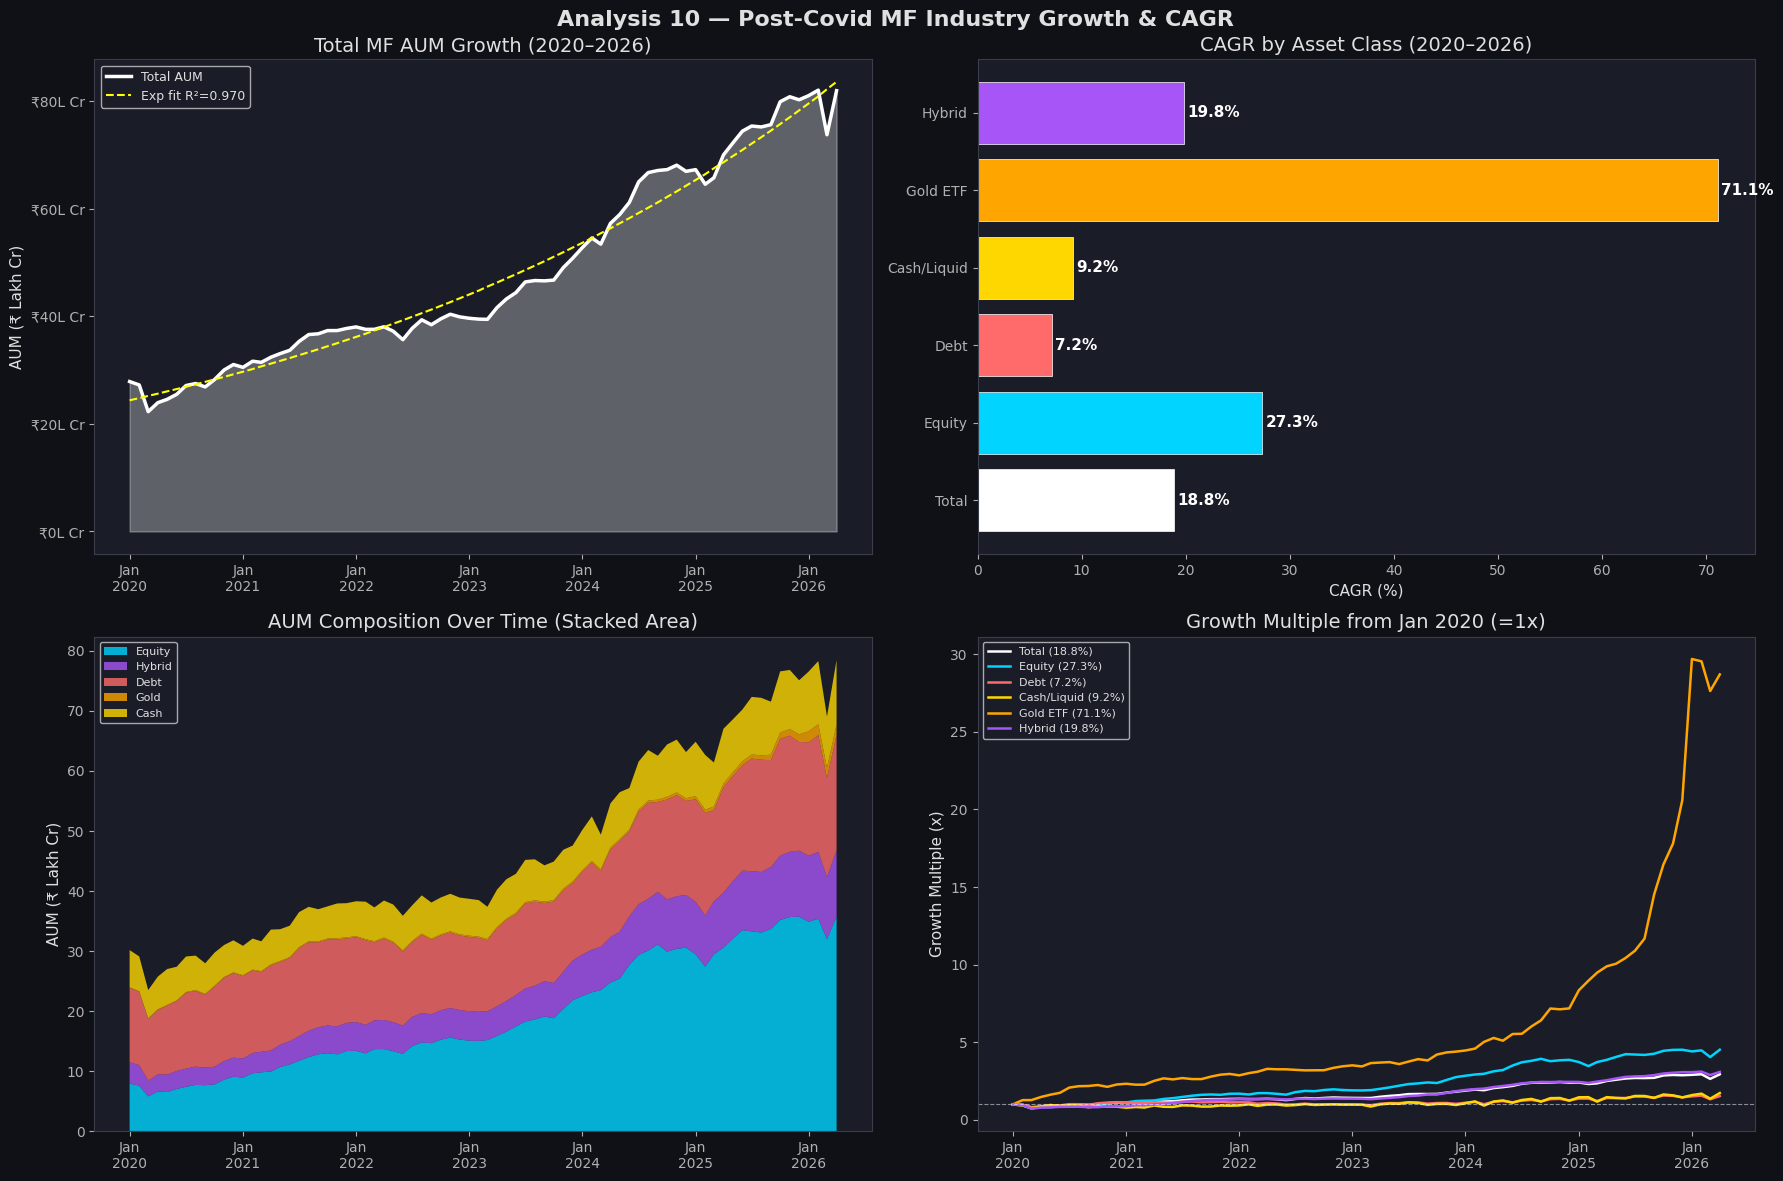

In [15]:
a10 = df.dropna(subset=['Total_AUM_Cr']).copy().sort_values('Month').reset_index(drop=True)

# CAGR function
def cagr(start, end, years):
    return ((end/start)**(1/years) - 1) * 100

start_row = a10.iloc[0]
end_row   = a10.iloc[-1]
years = (end_row['Month'] - start_row['Month']).days / 365.25

print("══════════════════════════════════════════")
print("  POST-COVID MF INDUSTRY GROWTH (2020-2026)")
print("══════════════════════════════════════════")
print(f"  Period : {start_row['Month'].strftime('%b %Y')} → {end_row['Month'].strftime('%b %Y')}  ({years:.1f} years)")
print()
cats = {
    'Total':       'Total_AUM_Cr',
    'Equity':      'Equity_AUM_Cr',
    'Debt':        'Debt_AUM_Cr',
    'Cash/Liquid': 'Cash_AUM_Cr',
    'Gold ETF':    'Gold_AUM_Cr',
    'Hybrid':      'Hybrid_AUM_Cr',
}
cagr_vals = {}
for name, col in cats.items():
    s = a10[col].iloc[0]; e = a10[col].iloc[-1]
    c = cagr(s, e, years)
    cagr_vals[name] = c
    mult = e/s
    dbl  = 72/c if c>0 else float('inf')
    print(f"  {name:<12}: ₹{s/1e5:.2f}L Cr → ₹{e/1e5:.2f}L Cr  |  CAGR={c:.1f}%  |  {mult:.1f}x  |  Doubles every {dbl:.1f} yrs")

# Exponential growth fit for total AUM
a10['T'] = np.arange(len(a10))
a10['log_AUM'] = np.log(a10['Total_AUM_Cr'])
Xe = sm.add_constant(a10['T'])
me = sm.OLS(a10['log_AUM'], Xe).fit()
monthly_growth_rate = (np.exp(me.params['T']) - 1)*100
print(f"\n  Exponential fit: monthly growth rate = {monthly_growth_rate:.2f}%  |  R²={me.rsquared:.4f}")
print(f"  Implied annual CAGR from exp fit: {(np.exp(me.params['T']*12)-1)*100:.1f}%")

# Figure
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Analysis 10 — Post-Covid MF Industry Growth & CAGR", fontsize=16, fontweight='bold')

# Total AUM waterfall
ax = axes[0,0]
ax.fill_between(a10['Month'], a10['Total_AUM_Cr']/1e5, alpha=0.3, color=PALETTE['total'])
ax.plot(a10['Month'], a10['Total_AUM_Cr']/1e5, color=PALETTE['total'], lw=2.5, label='Total AUM')
ax.plot(a10['Month'], np.exp(me.predict(Xe))/1e5, color='yellow', lw=1.5, linestyle='--', label=f'Exp fit R²={me.rsquared:.3f}')
ax.set_title("Total MF AUM Growth (2020–2026)")
ax.set_ylabel("AUM (₹ Lakh Cr)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x:.0f}L Cr'))
ax.legend()
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b\n%Y'))

# CAGR bar chart
ax = axes[0,1]
cagr_colors = [PALETTE['total'],PALETTE['equity'],PALETTE['debt'],PALETTE['cash'],PALETTE['gold'],PALETTE['hybrid']]
bars = ax.barh(list(cagr_vals.keys()), list(cagr_vals.values()), color=cagr_colors, edgecolor='white', lw=0.5)
for bar, val in zip(bars, cagr_vals.values()):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=11, color='white', fontweight='bold')
ax.set_title("CAGR by Asset Class (2020–2026)")
ax.set_xlabel("CAGR (%)")

# Category AUM over time — stacked area
ax = axes[1,0]
stack_cols = ['Equity_AUM_Cr','Hybrid_AUM_Cr','Debt_AUM_Cr','Gold_AUM_Cr','Cash_AUM_Cr']
stack_labels = ['Equity','Hybrid','Debt','Gold','Cash']
stack_colors = [PALETTE['equity'],PALETTE['hybrid'],PALETTE['debt'],PALETTE['gold'],PALETTE['cash']]
a10_clean = a10.dropna(subset=stack_cols)
ys = [a10_clean[c]/1e5 for c in stack_cols]
ax.stackplot(a10_clean['Month'], ys, labels=stack_labels, colors=[c+'CC' for c in stack_colors])
ax.set_title("AUM Composition Over Time (Stacked Area)")
ax.set_ylabel("AUM (₹ Lakh Cr)")
ax.legend(loc='upper left', fontsize=8)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b\n%Y'))

# Growth multiples
ax = axes[1,1]
for (name,col), color in zip(cats.items(), cagr_colors):
    s_val = a10[col].iloc[0]
    ax.plot(a10['Month'], a10[col]/s_val, color=color, lw=1.8, label=f'{name} ({cagr_vals[name]:.1f}%)')
ax.axhline(1, color='white', lw=0.8, linestyle='--', alpha=0.5)
ax.set_title("Growth Multiple from Jan 2020 (=1x)")
ax.set_ylabel("Growth Multiple (x)")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b\n%Y'))

plt.tight_layout()
plt.savefig('a10_growth_cagr.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()


---
## 📋 Statistical Tests Summary Table
All hypothesis tests with results and conclusions.


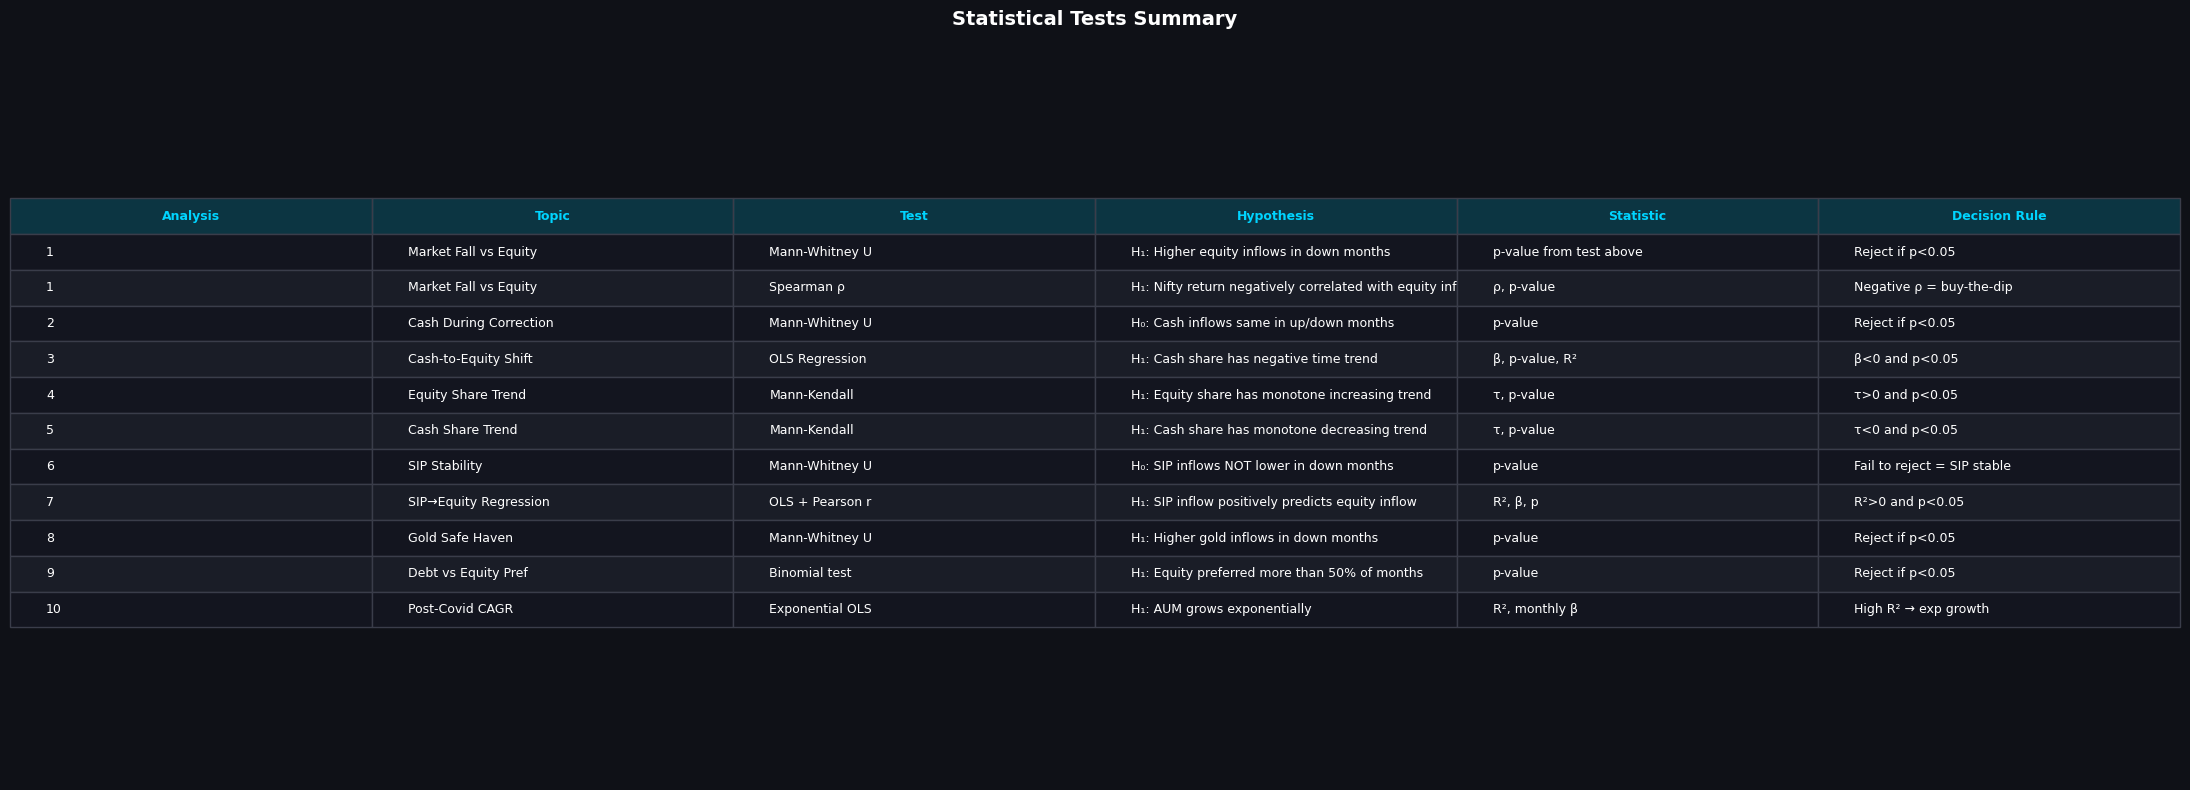

✅ All 10 analyses completed. Statistical tests run with proper hypothesis testing.


In [16]:
summary_data = [
    ["1","Market Fall vs Equity","Mann-Whitney U","H₁: Higher equity inflows in down months","p-value from test above","Reject if p<0.05"],
    ["1","Market Fall vs Equity","Spearman ρ","H₁: Nifty return negatively correlated with equity inflow","ρ, p-value","Negative ρ = buy-the-dip"],
    ["2","Cash During Correction","Mann-Whitney U","H₀: Cash inflows same in up/down months","p-value","Reject if p<0.05"],
    ["3","Cash-to-Equity Shift","OLS Regression","H₁: Cash share has negative time trend","β, p-value, R²","β<0 and p<0.05"],
    ["4","Equity Share Trend","Mann-Kendall","H₁: Equity share has monotone increasing trend","τ, p-value","τ>0 and p<0.05"],
    ["5","Cash Share Trend","Mann-Kendall","H₁: Cash share has monotone decreasing trend","τ, p-value","τ<0 and p<0.05"],
    ["6","SIP Stability","Mann-Whitney U","H₀: SIP inflows NOT lower in down months","p-value","Fail to reject = SIP stable"],
    ["7","SIP→Equity Regression","OLS + Pearson r","H₁: SIP inflow positively predicts equity inflow","R², β, p","R²>0 and p<0.05"],
    ["8","Gold Safe Haven","Mann-Whitney U","H₁: Higher gold inflows in down months","p-value","Reject if p<0.05"],
    ["9","Debt vs Equity Pref","Binomial test","H₁: Equity preferred more than 50% of months","p-value","Reject if p<0.05"],
    ["10","Post-Covid CAGR","Exponential OLS","H₁: AUM grows exponentially","R², monthly β","High R² → exp growth"],
]

df_summary = pd.DataFrame(summary_data, columns=["Analysis","Topic","Test","Hypothesis","Statistic","Decision Rule"])

fig, ax = plt.subplots(figsize=(22, 8))
ax.axis('off')
tbl = ax.table(cellText=df_summary.values, colLabels=df_summary.columns, loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(9); tbl.scale(1, 1.8)
for (row, col), cell in tbl.get_celld().items():
    cell.set_facecolor('#1A1D27' if row%2==0 else '#13151F')
    cell.set_edgecolor('#3A3D4A')
    cell.set_text_props(color='white')
    if row==0:
        cell.set_facecolor('#00D4FF30')
        cell.set_text_props(color='#00D4FF', fontweight='bold')
ax.set_title("Statistical Tests Summary", fontsize=14, fontweight='bold', pad=15, color='white')
plt.tight_layout()
plt.savefig('summary_table.png', dpi=150, bbox_inches='tight', facecolor='#0F1117')
plt.show()
print("✅ All 10 analyses completed. Statistical tests run with proper hypothesis testing.")


---
## 🎛️ Dashboard — Key Metrics at a Glance

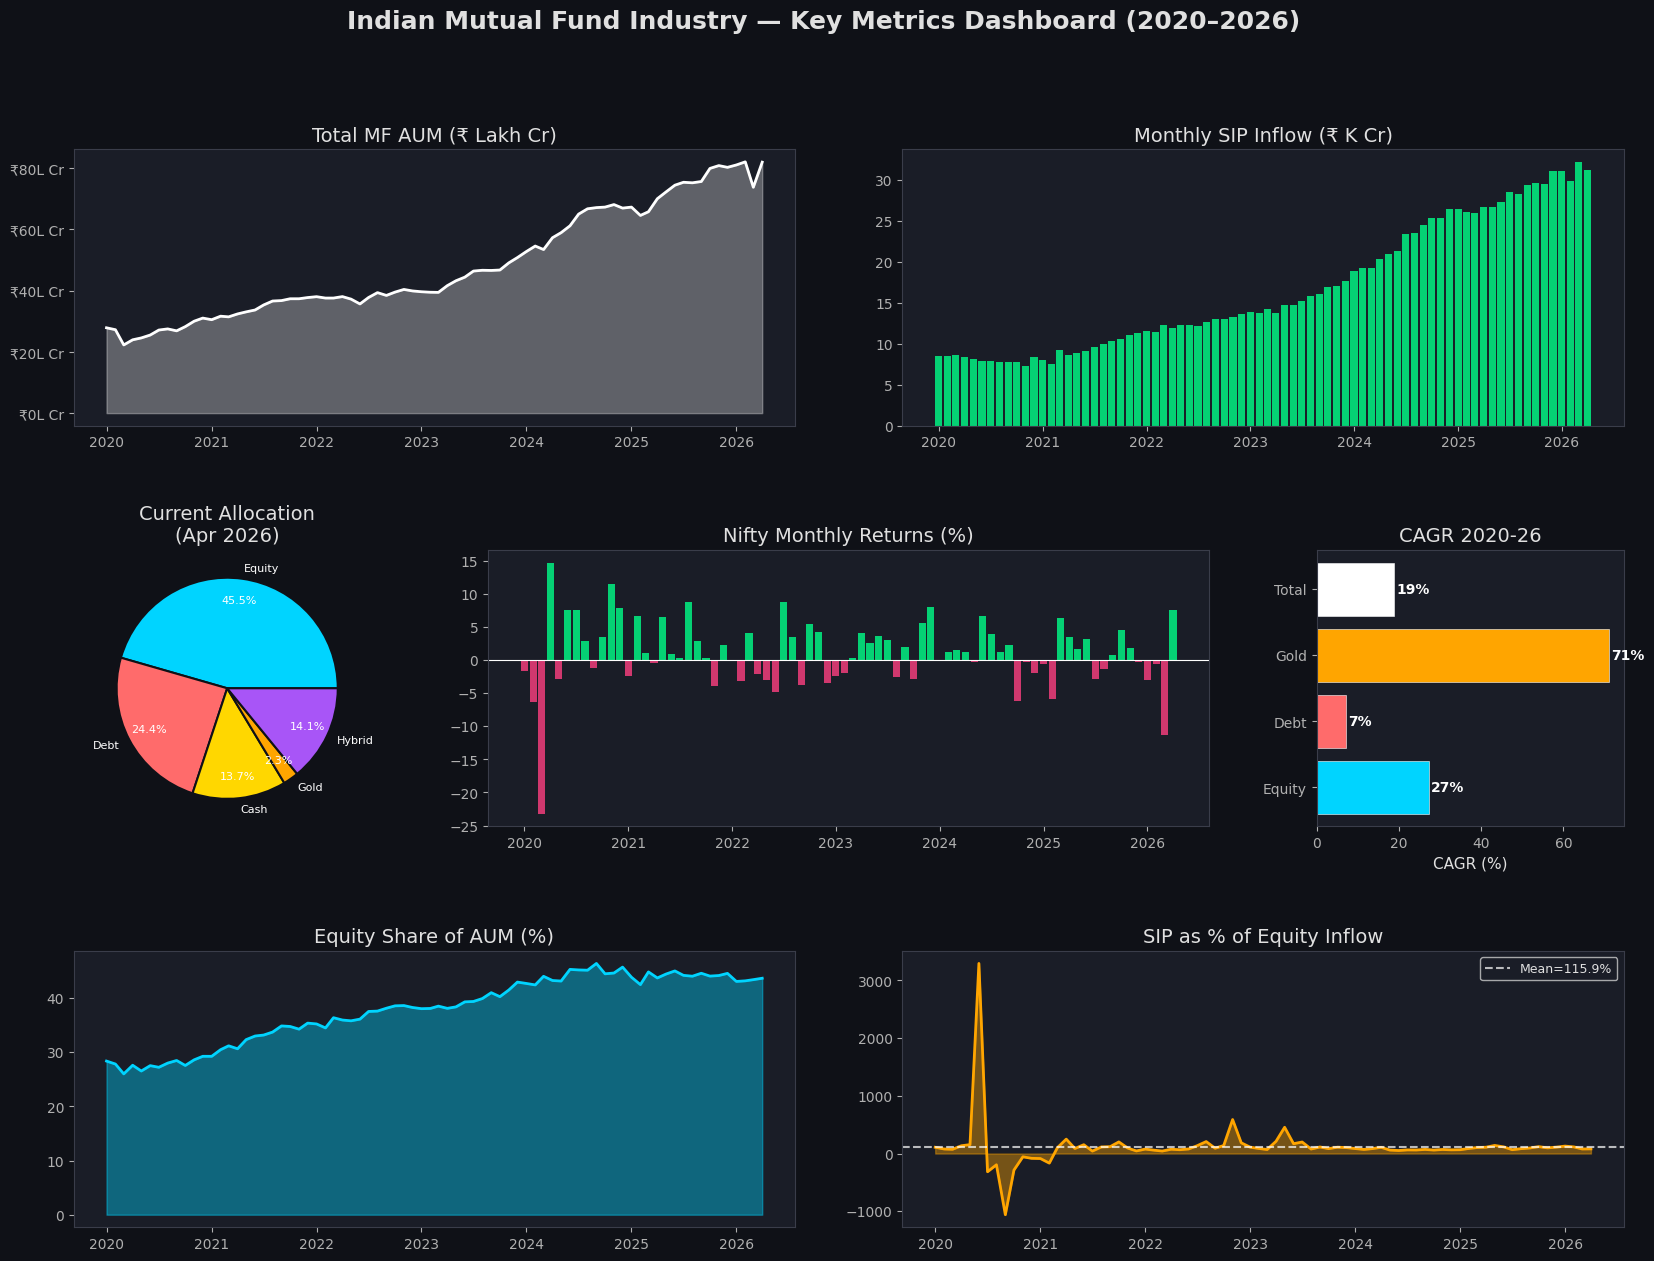

✅ Dashboard complete!


In [17]:
fig = plt.figure(figsize=(20, 14))
fig.suptitle("Indian Mutual Fund Industry — Key Metrics Dashboard (2020–2026)", 
             fontsize=18, fontweight='bold', y=0.98)

gs = fig.add_gridspec(3, 4, hspace=0.45, wspace=0.35)

a_dash = df.dropna(subset=['Total_AUM_Cr','Equity_AUM_Cr','SIP_Inflow_Cr','Nifty_Return_Pct']).copy()
a_dash = a_dash.sort_values('Month').reset_index(drop=True)

# 1. Total AUM
ax = fig.add_subplot(gs[0, :2])
ax.fill_between(a_dash['Month'], a_dash['Total_AUM_Cr']/1e5, alpha=0.3, color='#FFFFFF')
ax.plot(a_dash['Month'], a_dash['Total_AUM_Cr']/1e5, color='#FFFFFF', lw=2)
ax.set_title("Total MF AUM (₹ Lakh Cr)"); ax.set_facecolor('#1A1D27')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'₹{x:.0f}L Cr'))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))

# 2. SIP inflow
ax = fig.add_subplot(gs[0, 2:])
ax.bar(a_dash['Month'], a_dash['SIP_Inflow_Cr']/1000, color=PALETTE['sip'], alpha=0.8, width=25)
ax.set_title("Monthly SIP Inflow (₹ K Cr)"); ax.set_facecolor('#1A1D27')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))

# 3. Asset allocation pie (latest)
ax = fig.add_subplot(gs[1, 0])
latest = a_dash.iloc[-1]
pie_vals = [latest['Equity_AUM_Cr'], latest['Debt_AUM_Cr'], latest['Cash_AUM_Cr'],
            latest['Gold_AUM_Cr'], latest['Hybrid_AUM_Cr']]
pie_lbls = ['Equity','Debt','Cash','Gold','Hybrid']
pie_cols = [PALETTE['equity'],PALETTE['debt'],PALETTE['cash'],PALETTE['gold'],PALETTE['hybrid']]
ax.pie(pie_vals, labels=pie_lbls, colors=pie_cols, autopct='%1.1f%%', pctdistance=0.8,
       textprops={'color':'white','fontsize':8}, wedgeprops={'edgecolor':'#0F1117','linewidth':1.5})
ax.set_title("Current Allocation\n(" + latest['Month'].strftime('%b %Y') + ")")

# 4. Nifty returns heatmap-style
ax = fig.add_subplot(gs[1, 1:3])
c_map = [PALETTE['pos'] if v>=0 else PALETTE['neg'] for v in a_dash['Nifty_Return_Pct']]
ax.bar(a_dash['Month'], a_dash['Nifty_Return_Pct'], color=c_map, alpha=0.8, width=25)
ax.axhline(0, color='white', lw=0.8)
ax.set_title("Nifty Monthly Returns (%)"); ax.set_facecolor('#1A1D27')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))

# 5. CAGR mini bar
ax = fig.add_subplot(gs[1, 3])
cagr_mini = {'Equity':cagr_vals['Equity'],'Debt':cagr_vals['Debt'],'Gold':cagr_vals['Gold ETF'],'Total':cagr_vals['Total']}
ax.barh(list(cagr_mini.keys()), list(cagr_mini.values()),
        color=[PALETTE['equity'],PALETTE['debt'],PALETTE['gold'],PALETTE['total']], edgecolor='white', lw=0.4)
for i,(k,v) in enumerate(cagr_mini.items()):
    ax.text(v+0.5, i, f'{v:.0f}%', va='center', fontsize=10, color='white', fontweight='bold')
ax.set_title("CAGR 2020-26"); ax.set_xlabel("CAGR (%)")

# 6. Equity share over time
ax = fig.add_subplot(gs[2, :2])
ax.fill_between(a_dash['Month'], a_dash['Equity_Share_Pct'].ffill(), alpha=0.4, color=PALETTE['equity'])
ax.plot(a_dash['Month'], a_dash['Equity_Share_Pct'].ffill(), color=PALETTE['equity'], lw=2)
ax.set_title("Equity Share of AUM (%)"); ax.set_facecolor('#1A1D27')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))

# 7. SIP coverage
ax = fig.add_subplot(gs[2, 2:])
sip_cov = a_dash['SIP_Inflow_Cr'] / a_dash['Equity_Inflow_Cr'] * 100
ax.fill_between(a_dash['Month'], sip_cov, alpha=0.4, color=PALETTE['gold'])
ax.plot(a_dash['Month'], sip_cov, color=PALETTE['gold'], lw=2)
ax.axhline(sip_cov.mean(), color='white', lw=1.5, linestyle='--', alpha=0.7, label=f'Mean={sip_cov.mean():.1f}%')
ax.set_title("SIP as % of Equity Inflow"); ax.legend(fontsize=9); ax.set_facecolor('#1A1D27')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))

plt.savefig('dashboard.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Dashboard complete!")
